# TP 1 - Problema 4: Clasificación de razas de perros con una CNN desde cero

Objetivo: clasificar imágenes de razas de perros con una red neuronal
convolucional (CNN) que se entrena desde cero. No se usan modelos
preentrenados ni transfer learning. Todos los pesos parten de una
inicialización aleatoria.

Dataset: *70 Dog Breeds Image Dataset* (`train`, `valid` y `test`). Se trabaja
con un subconjunto de **8 razas**, como recomienda el enunciado.

Condiciones de trabajo que afectan el diseño:

- **Se entrena en una GPU de Google Colab**, con imágenes de 128 x 128 píxeles
  (uno de los ejemplos del enunciado). El notebook también corre en CPU, pero
  mucho más lento.
- **Validación y test son chicos.** Cada raza tiene 10 imágenes en cada uno. Con 8
  razas son 80 imágenes por conjunto. Un acierto de más o de menos cambia la
  exactitud en 1.25 puntos. Por eso cada experimento se repite con **3 semillas**,
  y se reportan el promedio y el desvío.
- **El test no elige nada.** Los modelos se eligen solo con validación. El enunciado
  pide la exactitud de test de cada experimento, y se reporta en la tabla.

Experimentos: E1 (línea base), E2 (más profundidad, tamaño de filtro y stride), E3 (bloques residuales) y E4 (regularización y data augmentation). E5 corrige la falla de E4 con lo que mide el diagnóstico, y se diseñó después de ver los resultados. El notebook guarda checkpoints y retoma un entrenamiento interrumpido.

**Cómo ejecutarlo en Colab.** Elegir un entorno con GPU (Entorno de ejecución,
Cambiar tipo de entorno, GPU) y ejecutar todas las celdas. La celda de la
sección 1.2 monta Google Drive y descarga el dataset. Los resultados, los
checkpoints y las figuras quedan en la carpeta `AA2_TP1_P4` de Drive. Si la
sesión se corta, ejecutar todo otra vez: las corridas terminadas se cargan de
Drive, y la corrida interrumpida sigue desde su último checkpoint.

### Configuración

Se importan las librerías, se fija la semilla global (42) y se elige el
dispositivo. Las semillas de cada entrenamiento se fijan por separado, dentro
de la función de entrenamiento (sección 5). Así cada corrida se repite igual,
sin importar cuántos números aleatorios consumió la celda anterior. Este fue el
problema medido en el Problema 2.

En GPU, el notebook pide a PyTorch algoritmos deterministas. Sin ese pedido,
algunas operaciones de cuDNN dan resultados un poco distintos en cada corrida. La
variable `CUBLAS_WORKSPACE_CONFIG` hace lo mismo para cuBLAS, y tiene que estar
definida antes de usar la GPU. La sección 5.2 mide si la repetición es exacta.

In [1]:
import os
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')

import copy
import hashlib
import pickle
import sys
import time
import urllib.request
import zipfile
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import confusion_matrix
from scipy.stats import binomtest

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)
IN_COLAB = 'google.colab' in sys.modules

plt.rcParams.update({
    'figure.figsize': (10, 4.5),
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3
})
sns.set_palette("muted")
print(f"torch {torch.__version__}, dispositivo: {DEVICE}, Colab: {IN_COLAB}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch 2.11.0+cu130, dispositivo: cuda, Colab: True
GPU: Tesla T4


Las librerías quedaron cargadas. La salida muestra el dispositivo de
entrenamiento. En Colab con GPU, muestra el modelo de la GPU.

## 1. Selección de razas y carga de datos

### 1.1 Qué razas se usan y por qué

El dataset tiene 70 razas. Se eligieron 8, **antes de entrenar ningún modelo**. Solo
se miró cuántas imágenes tiene cada raza. El enunciado pide justificar la
selección. Se busca un problema con partes fáciles y partes difíciles, para que el
análisis de confusiones tenga contenido.

| Grupo | Razas | Por qué |
|---|---|---|
| Trío similar | Border Collie, Collie, Bearded Collie | Pelo largo y colores parecidos. Es la parte difícil. |
| Par similar | Labrador, Golden Retriever | Misma talla y cabeza parecida. Cambia el color y el pelo. |
| Distintas | Pug, Siberian Husky, Chihuahua | Cara, talla y pelaje muy diferentes. Es la parte fácil. |

### 1.2 Ubicación de los datos y de los resultados

En Colab se monta Google Drive. Los resultados, los checkpoints y las figuras van
a una carpeta de Drive, porque el disco de la sesión de Colab se borra al
cerrarla. El dataset va al disco de la sesión, que es más rápido. Si no está, se
descarga del enlace de Drive del enunciado y se descomprime. Fuera de
Colab, todo queda en la carpeta del notebook.

In [2]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    WORK_DIR = Path('/content/drive/MyDrive/AA2_TP1_P4')
    DATA_DIR = Path('/content/datasets/PROBLEMA 4')
else:
    WORK_DIR = Path('.')
    DATA_DIR = Path('datasets/PROBLEMA 4')
WORK_DIR.mkdir(parents=True, exist_ok=True)

DATASET_URL = ('https://drive.usercontent.google.com/download?'
               'id=1aw3nX2c3Nk8EURGKV7hzTZJd-OaVuzmu&export=download&confirm=t')
if not (DATA_DIR / 'train').exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    zip_path = DATA_DIR / 'dogs.zip'
    print("Descargando el dataset...")
    urllib.request.urlretrieve(DATASET_URL, zip_path)
    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(DATA_DIR)
    zip_path.unlink()
print(f"Datos: {DATA_DIR.resolve()}")
print(f"Resultados: {WORK_DIR.resolve()}")
print("Carpetas del dataset:", sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir()))

Mounted at /content/drive
Descargando el dataset...
Datos: /content/datasets/PROBLEMA 4
Resultados: /content/drive/MyDrive/AA2_TP1_P4
Carpetas del dataset: ['test', 'train', 'valid']


La celda muestra dónde quedan los datos y los resultados. El dataset tiene las
carpetas `train`, `valid` y `test`, como en Kaggle.

### 1.3 Carga de las imágenes

Decisiones de carga:

- **Resolución de 128 x 128.** Las imágenes originales son de 224 x 224. El
  enunciado da 128 y 224 como ejemplos. Con 128, el costo por imagen es unas 3
  veces menor, y es posible repetir cada experimento con 3 semillas. Se pierde
  detalle fino, y eso afecta sobre todo al trío de Collies.
- **Todo en memoria.** El subconjunto tiene unas 1100 imágenes. Todo se carga a
  tensores `uint8` una sola vez.
- **Se verifica que no haya imágenes repetidas entre train, validación y test.**
  Para eso se calcula el hash MD5 del archivo de cada imagen. Una imagen repetida sube la exactitud de test sin que el modelo generalice mejor. Si aparecen repetidas, se quitan de
  train, y val y test quedan como vienen. Así los conjuntos de
  evaluación no cambian.

In [3]:
BREEDS = ["Border Collie", "Collie", "Bearded Collie", "Labrador",
          "Golden Retriever", "Pug", "Siberian Husky", "Chihuahua"]
NUM_CLASSES = len(BREEDS)
RESOLUTION = 128


def load_split(split):
    images, labels, hashes = [], [], []
    original_sizes, original_modes = Counter(), Counter()
    for label, breed in enumerate(BREEDS):
        folder = DATA_DIR / split / breed
        for path in sorted(folder.iterdir()):
            hashes.append(hashlib.md5(path.read_bytes()).hexdigest())
            with Image.open(path) as img:
                original_sizes[img.size] += 1
                original_modes[img.mode] += 1
                img = img.convert('RGB').resize((RESOLUTION, RESOLUTION), Image.BILINEAR)
                images.append(np.asarray(img))
            labels.append(label)
    tensor = torch.from_numpy(np.stack(images)).permute(0, 3, 1, 2).contiguous()
    return tensor, torch.tensor(labels), hashes, original_sizes, original_modes


start = time.perf_counter()
X_train_raw, y_train, hash_train, sizes_train, modes_train = load_split('train')
X_val_raw, y_val, hash_val, sizes_val, modes_val = load_split('valid')
X_test_raw, y_test, hash_test, sizes_test, modes_test = load_split('test')
print(f"Carga: {time.perf_counter() - start:.1f} s")

for name, tensor, labels in [('train', X_train_raw, y_train), ('val', X_val_raw, y_val),
                             ('test', X_test_raw, y_test)]:
    assert tensor.shape[1:] == (3, RESOLUTION, RESOLUTION) and tensor.dtype == torch.uint8
    assert len(tensor) == len(labels)
    print(f"{name}: {tuple(tensor.shape)}, {tensor.dtype}, rango [{tensor.min()}, {tensor.max()}]")

print("\nTamaños originales:", dict(sizes_train + sizes_val + sizes_test))
print("Modos originales:", dict(modes_train + modes_val + modes_test))

overlap_train_val = set(hash_train) & set(hash_val)
overlap_train_test = set(hash_train) & set(hash_test)
overlap_val_test = set(hash_val) & set(hash_test)
print(f"Imagenes repetidas (mismo archivo): train-val {len(overlap_train_val)}, "
      f"train-test {len(overlap_train_test)}, val-test {len(overlap_val_test)}")
print(f"Repetidas dentro de train: {len(hash_train) - len(set(hash_train))}")

# Se quitan de train las imagenes que tambien estan en val o en test, y las repetidas dentro de train.
# Val y test quedan intactos.
seen, keep = set(hash_val) | set(hash_test), []
for position, digest in enumerate(hash_train):
    if digest not in seen:
        keep.append(position)
        seen.add(digest)
removed = sorted(set(range(len(hash_train))) - set(keep))
removed_by_breed = Counter(BREEDS[int(y_train[k])] for k in removed)
keep = torch.tensor(keep)
X_train_raw, y_train = X_train_raw[keep], y_train[keep]
print(f"Imagenes quitadas de train: {len(removed)} {dict(removed_by_breed)}")
print(f"Train despues de limpiar: {tuple(X_train_raw.shape)}")
assert len(overlap_val_test) == 0

Carga: 1.5 s
train: (928, 3, 128, 128), torch.uint8, rango [0, 255]
val: (80, 3, 128, 128), torch.uint8, rango [0, 255]
test: (80, 3, 128, 128), torch.uint8, rango [0, 255]

Tamaños originales: {(224, 224): 1088}
Modos originales: {'RGB': 1088}
Imagenes repetidas (mismo archivo): train-val 1, train-test 5, val-test 0
Repetidas dentro de train: 2
Imagenes quitadas de train: 8 {'Border Collie': 4, 'Collie': 1, 'Labrador': 2, 'Chihuahua': 1}
Train despues de limpiar: (920, 3, 128, 128)


Las imágenes se cargaron en 1.5 s. Todas las verificaciones pasaron:

- Train tiene 928 imágenes, y validación y test tienen 80 cada uno. Todas son
  `uint8`, con valores de 0 a 255.
- Las 1088 imágenes originales son de 224 x 224 y en RGB. No hay que tratar
  imágenes en escala de grises ni de otro tamaño.

**Imágenes repetidas.** El hash encontró 8 archivos de train repetidos: 1
también está en validación, 5 en test y 2 dos veces dentro de train. Sin este control, 5 de las 80 imágenes de test también están en train. Se quitaron los 8 de train (4 de Border
Collie, 1 de Collie, 2 de Labrador y 1 de Chihuahua). Train queda con 920
imágenes. Validación y test no tienen repetidas entre sí.

## 2. Análisis exploratorio de datos (EDA)

### 2.1 Cantidad de imágenes por raza

Se cuentan las imágenes por raza y por conjunto. El desbalance de train importa
para elegir la métrica. Si hay mucho desbalance, la exactitud global favorece a
las razas grandes.

In [4]:
counts = pd.DataFrame({
    'train': [int((y_train == k).sum()) for k in range(NUM_CLASSES)],
    'val': [int((y_val == k).sum()) for k in range(NUM_CLASSES)],
    'test': [int((y_test == k).sum()) for k in range(NUM_CLASSES)],
}, index=BREEDS)
counts['% de train'] = (counts['train'] / counts['train'].sum() * 100).round(1)
print(counts.to_string())
print(f"\nTotal: train {counts['train'].sum()}, val {counts['val'].sum()}, test {counts['test'].sum()}")
print(f"Razon entre la raza mas grande y la mas chica en train: "
      f"{counts['train'].max() / counts['train'].min():.2f}")
print(f"Exactitud de una prediccion constante en val y test (balanceados): {1 / NUM_CLASSES:.3f}")

                  train  val  test  % de train
Border Collie       108   10    10        11.7
Collie              113   10    10        12.3
Bearded Collie       79   10    10         8.6
Labrador            159   10    10        17.3
Golden Retriever    127   10    10        13.8
Pug                 148   10    10        16.1
Siberian Husky       79   10    10         8.6
Chihuahua           107   10    10        11.6

Total: train 920, val 80, test 80
Razon entre la raza mas grande y la mas chica en train: 2.01
Exactitud de una prediccion constante en val y test (balanceados): 0.125


**Train tiene un desbalance moderado.** Va de 79 imágenes (Bearded Collie y
Siberian Husky) a 159 (Labrador), una razón de 2.01. Labrador es el 17.3% de
train. Validación y test están balanceados, con 10 imágenes por raza.

Decisiones:

- **Sin ponderación de clases.** Una razón de 2 es mucho menor que la del
  Problema 1 (19.5). La sección 7.3 mira si el modelo prefiere las razas
  con más imágenes.
- **La exactitud es una métrica válida** en validación y test, porque están
  balanceados. La referencia es 0.125, la exactitud de predecir siempre la misma
  raza.
- **La exactitud por raza se mide con 10 imágenes.** Un resultado de 5 de 10
  tiene un intervalo de Wilson de 95% de 0.24 a 0.76. Por eso las razas no se
  ordenan por su exactitud.

### 2.2 Muestra de imágenes

Se muestran 6 imágenes aleatorias de train por raza. El objetivo es ver en qué se
parecen las razas y qué variedad tiene cada una: poses, fondos, encuadres. Se usa
un generador propio para que la muestra no dependa de otras celdas.

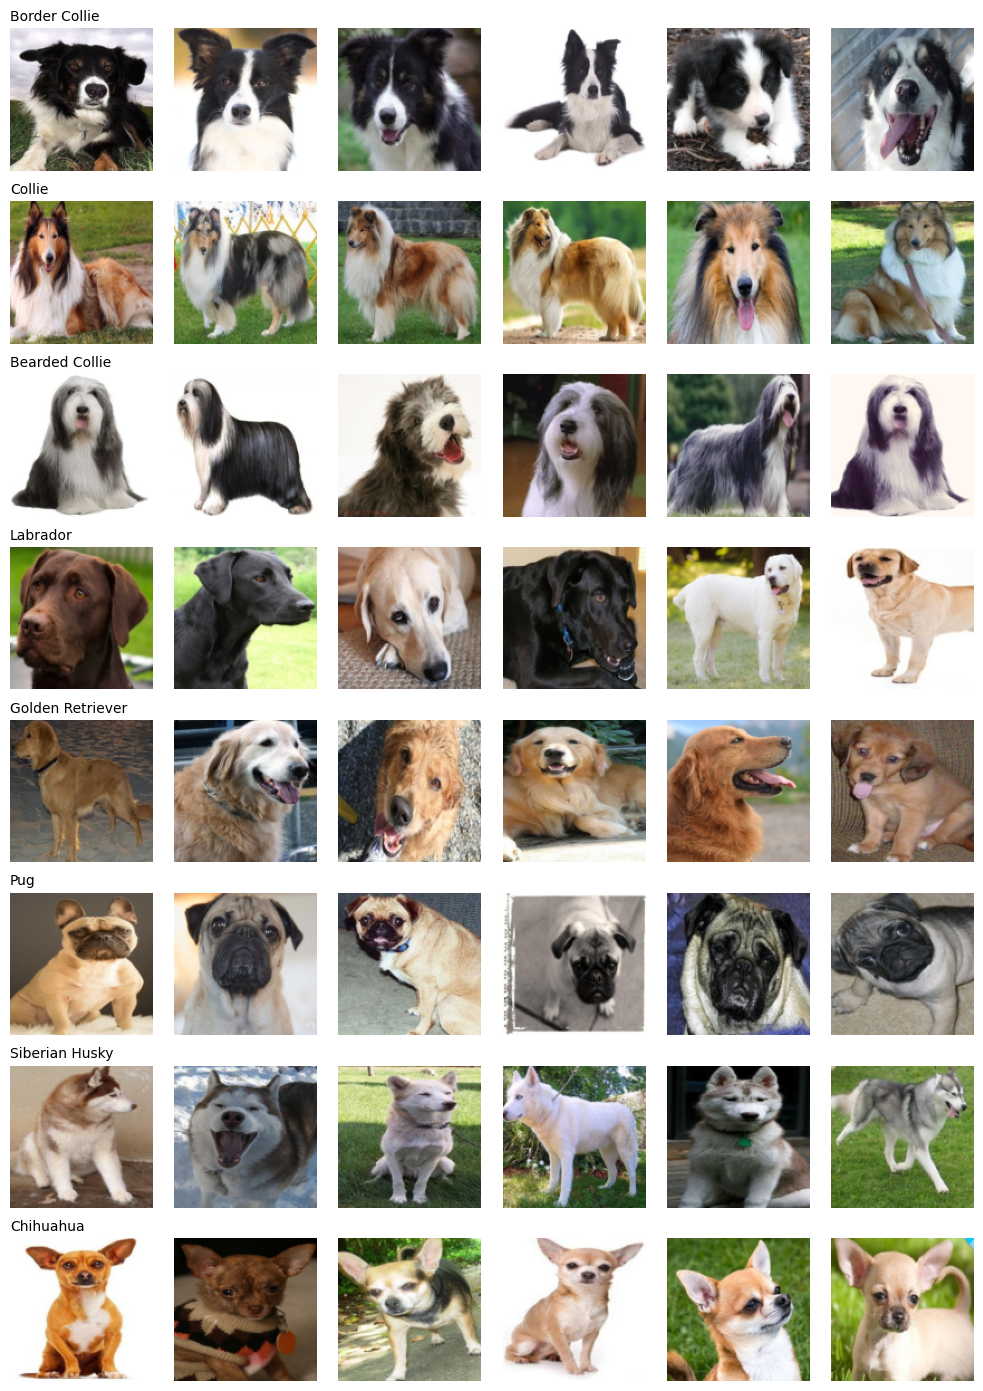

In [5]:
sample_rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(NUM_CLASSES, 6, figsize=(10, 14))
for k, breed in enumerate(BREEDS):
    chosen = sample_rng.choice(np.where(y_train.numpy() == k)[0], size=6, replace=False)
    for j, index in enumerate(chosen):
        axes[k, j].imshow(X_train_raw[index].permute(1, 2, 0).numpy())
        axes[k, j].axis('off')
        if j == 0:
            axes[k, j].set_title(breed, loc='left', fontsize=10)
plt.tight_layout()
plt.savefig(WORK_DIR / 'p4_01_muestra_imagenes.png', dpi=110, bbox_inches='tight')
plt.show()

La muestra muestra mucha variedad dentro de cada raza. Esta es una lectura
de las 48 imágenes, no una medición.

- **Poses, fondos y encuadres distintos.** Hay primeros planos de la cara, perros
  de cuerpo entero, fondos de pasto, de interior y de estudio (fondo blanco).
- **El color no define la raza.** Labrador aparece negro, chocolate y amarillo.
  El Labrador amarillo y el Golden Retriever tienen un color parecido.
- **El trío de Collies se distingue por el color y el pelo.** Border Collie es
  casi siempre blanco y negro. Collie es marrón y blanco, de pelo largo. Bearded
  Collie es gris y blanco, con pelo largo sobre la cara.
- **Siberian Husky es variado.** Hay perros grises y blancos típicos, y también
  perros blancos o crema que no tienen la máscara gris de la raza.

Estas observaciones explican algunas confusiones de la sección 7.3.

## 3. Preprocesamiento y data augmentation

### 3.1 Normalización

El enunciado permite normalizar con la media y el desvío de train. Se hace eso,
por canal. Las estadísticas se calculan **solo con train**. Si se calculan con val o test, se filtra información de esos conjuntos. No se usan los valores de ImageNet, porque
el dataset es distinto y no hay motivo para depender de otro conjunto.

In [6]:
train_float = X_train_raw.float() / 255
channel_mean = train_float.mean(dim=(0, 2, 3))
channel_std = train_float.std(dim=(0, 2, 3))
del train_float


def normalize(raw):
    return ((raw.float() / 255) - channel_mean[None, :, None, None]) / channel_std[None, :, None, None]


X_train, X_val, X_test = normalize(X_train_raw), normalize(X_val_raw), normalize(X_test_raw)
print(f"Media por canal (train): {channel_mean.numpy().round(4)}")
print(f"Desvio por canal (train): {channel_std.numpy().round(4)}")
print(f"Train normalizado: media {X_train.mean(dim=(0, 2, 3)).numpy().round(4)}, "
      f"desvio {X_train.std(dim=(0, 2, 3)).numpy().round(4)}")
print(f"Val normalizado: media {X_val.mean(dim=(0, 2, 3)).numpy().round(3)}, "
      f"desvio {X_val.std(dim=(0, 2, 3)).numpy().round(3)}")

Media por canal (train): [0.5366 0.502  0.4388]
Desvio por canal (train): [0.2824 0.2751 0.2816]
Train normalizado: media [ 0.  0. -0.], desvio [1. 1. 1.]
Val normalizado: media [-0.073 -0.088 -0.078], desvio [0.938 0.922 0.931]


La media por canal de train es 0.537, 0.502 y 0.439 (rojo, verde y azul), y el
desvío es cerca de 0.28 en los tres. Después de normalizar, train tiene media 0 y
desvío 1 en cada canal, como se espera.

**Validación no queda exactamente centrada.** Su media es de -0.07 a -0.09 y su
desvío de 0.92 a 0.94. Las imágenes de validación son un poco más oscuras y
tienen un poco menos de contraste que las de train. La diferencia es chica. No se
corrige, porque corregirla exige usar las estadísticas de validación, y eso
filtra información.

### 3.2 Pipeline de data augmentation

El enunciado pide augmentation **solo sobre train**. Torchvision no está instalado
en el entorno local del proyecto. Las transformaciones se escriben con tensores de
PyTorch. Actúan sobre un lote completo, y cada imagen recibe parámetros propios.

Transformaciones y rangos (`AUGMENT`):

- **Volteo horizontal**, con probabilidad 0.5. Un perro espejado sigue siendo de
  la misma raza.
- **Rotación** de -15 a +15 grados.
- **Zoom** de 0.9 a 1.1 y **traslación** de hasta un 10% del ancho en cada eje.
  Estas dos hacen de recorte aleatorio. Los bordes se rellenan por reflexión.
- **Contraste** de 0.8 a 1.2 y **brillo** de -0.2 a +0.2 (en unidades del
  espacio normalizado).

Decisiones:

- **Rangos moderados.** Con una rotación fuerte o un zoom grande, la cara sale del encuadre en algunas imágenes. En razas parecidas, la cara es la pista principal.
- **Sin volteo vertical.** Un perro boca abajo no aparece en datos reales.
- **Generador propio.** Los parámetros salen de un `torch.Generator` aparte del
  que mezcla los lotes. Así la augmentation no cambia el orden de los datos.
- **Dos funciones.** `sample_augment_params` sortea los parámetros y
  `apply_augment` los aplica. Así es posible probar `apply_augment` con parámetros
  elegidos a mano.

Las pruebas usan las mismas funciones que el entrenamiento. Tres verifican la magnitud de la traslación, de la rotación y del zoom. Las otras verifican la transformación neutra, el volteo, la repetición con la misma semilla, y que la entrada no cambie.

Prueba 1, rangos en cero: error maximo 4.80e-06
Prueba 2, volteo contra x.flip(3): error maximo 6.23e-06
Prueba 3, traslacion 0.1: el punto se mueve 12.80 px en x (esperado 12.8) y 0.00 px en y (esperado 0)
Prueba 4, rotacion de 30 grados: el punto gira 30.00 grados
Prueba 5, zoom 1.1: distancia al centro x 0.9087 (esperado 0.9091)
Prueba 6, misma semilla: iguales True, semilla distinta: iguales False
Prueba 7, el lote de entrada no cambia: True


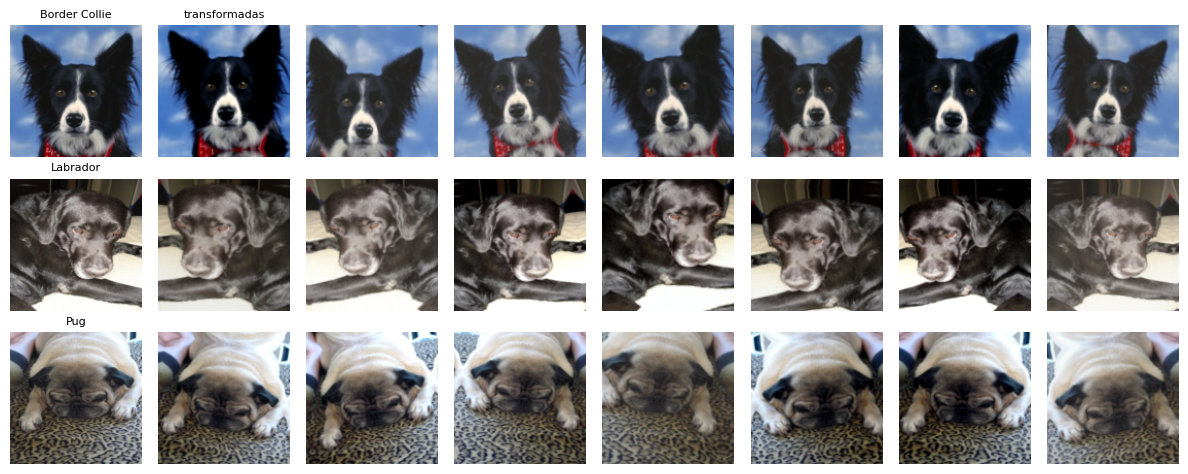

In [7]:
AUGMENT = dict(flip_probability=0.5, max_rotation_degrees=15.0, max_zoom=0.1,
               max_shift=0.1, max_contrast=0.2, max_brightness=0.2)
NEUTRAL = {key: 0.0 for key in AUGMENT}


def sample_augment_params(n, generator, settings=AUGMENT):
    # Un valor por imagen. Los sorteos se hacen en CPU, con el generador de la corrida.
    uniform = lambda limit: (2 * torch.rand(n, generator=generator) - 1) * limit
    return dict(flip=torch.rand(n, generator=generator) < settings['flip_probability'],
                angle=uniform(settings['max_rotation_degrees']) * np.pi / 180,
                zoom=1 + uniform(settings['max_zoom']),
                shift_x=uniform(settings['max_shift']), shift_y=uniform(settings['max_shift']),
                contrast=1 + uniform(settings['max_contrast']),
                brightness=uniform(settings['max_brightness']))


def apply_augment(x, params):
    # shift esta en fraccion del ancho. affine_grid usa coordenadas de -1 a 1 (ancho 2).
    p = {key: value.to(x.device) for key, value in params.items()}
    x = torch.where(p['flip'][:, None, None, None], x.flip(3), x)
    cos, sin = torch.cos(p['angle']), torch.sin(p['angle'])
    theta = torch.stack([
        torch.stack([p['zoom'] * cos, -p['zoom'] * sin, 2 * p['shift_x']], dim=1),
        torch.stack([p['zoom'] * sin, p['zoom'] * cos, 2 * p['shift_y']], dim=1),
    ], dim=1).to(x.dtype)
    grid = F.affine_grid(theta, list(x.shape), align_corners=False)
    x = F.grid_sample(x, grid, mode='bilinear', padding_mode='reflection', align_corners=False)
    return x * p['contrast'][:, None, None, None] + p['brightness'][:, None, None, None]


def augment_batch(x, generator, settings=AUGMENT):
    return apply_augment(x, sample_augment_params(len(x), generator, settings))


def one_image_params(**changes):
    params = dict(flip=torch.tensor([False]), angle=torch.zeros(1), zoom=torch.ones(1),
                  shift_x=torch.zeros(1), shift_y=torch.zeros(1),
                  contrast=torch.ones(1), brightness=torch.zeros(1))
    params.update({key: torch.tensor([value]) for key, value in changes.items()})
    return params


def centroid(image):
    # Centro de masa (fila, columna) de una imagen de un canal
    rows, cols = torch.meshgrid(torch.arange(RESOLUTION).float(), torch.arange(RESOLUTION).float(),
                                indexing='ij')
    total = image.sum()
    return float((image * rows).sum() / total), float((image * cols).sum() / total)


batch = X_train[:16]
center = RESOLUTION / 2 - 0.5

# Prueba 1: con los rangos en cero, augment_batch no cambia la imagen.
neutral_out = augment_batch(batch, torch.Generator().manual_seed(0), NEUTRAL)
print(f"Prueba 1, rangos en cero: error maximo {(neutral_out - batch).abs().max():.2e}")

# Prueba 2: el volteo es un espejo horizontal exacto.
flip_out = augment_batch(batch, torch.Generator().manual_seed(0), {**NEUTRAL, 'flip_probability': 1.0})
print(f"Prueba 2, volteo contra x.flip(3): error maximo {(flip_out - batch.flip(3)).abs().max():.2e}")

# Prueba 3: una traslacion de 0.1 mueve un punto el 10% del ancho.
dot = torch.zeros(1, 1, RESOLUTION, RESOLUTION)
dot[0, 0, 60:68, 60:68] = 1.0
before_row, before_col = centroid(dot[0, 0])
moved = apply_augment(dot, one_image_params(shift_x=0.1))
after_row, after_col = centroid(moved[0, 0])
print(f"Prueba 3, traslacion 0.1: el punto se mueve {abs(after_col - before_col):.2f} px "
      f"en x (esperado {0.1 * RESOLUTION:.1f}) y {abs(after_row - before_row):.2f} px en y (esperado 0)")

# Prueba 4: una rotacion de 30 grados gira un punto 30 grados alrededor del centro.
off_center = torch.zeros(1, 1, RESOLUTION, RESOLUTION)
off_center[0, 0, 60:68, 96:104] = 1.0
row_0, col_0 = centroid(off_center[0, 0])
rotated = apply_augment(off_center, one_image_params(angle=float(np.radians(30))))
row_1, col_1 = centroid(rotated[0, 0])
turn = np.degrees(np.arctan2(row_1 - center, col_1 - center) - np.arctan2(row_0 - center, col_0 - center))
print(f"Prueba 4, rotacion de 30 grados: el punto gira {abs(turn):.2f} grados")

# Prueba 5: un zoom de 1.1 acerca el punto al centro en un factor 1 / 1.1.
zoomed = apply_augment(off_center, one_image_params(zoom=1.1))
row_2, col_2 = centroid(zoomed[0, 0])
ratio = np.hypot(row_2 - center, col_2 - center) / np.hypot(row_0 - center, col_0 - center)
print(f"Prueba 5, zoom 1.1: distancia al centro x {ratio:.4f} (esperado {1 / 1.1:.4f})")

# Prueba 6: misma semilla, mismo resultado. Semilla distinta, resultado distinto.
out_a = augment_batch(batch, torch.Generator().manual_seed(0))
out_b = augment_batch(batch, torch.Generator().manual_seed(0))
out_c = augment_batch(batch, torch.Generator().manual_seed(1))
print(f"Prueba 6, misma semilla: iguales {torch.equal(out_a, out_b)}, "
      f"semilla distinta: iguales {torch.equal(out_a, out_c)}")

# Prueba 7: la funcion no modifica el lote de entrada.
before = batch.clone()
augment_batch(batch, torch.Generator().manual_seed(0))
print(f"Prueba 7, el lote de entrada no cambia: {torch.equal(before, batch)}")


def to_display(x):
    restored = x * channel_std[:, None, None] + channel_mean[:, None, None]
    return restored.clamp(0, 1).permute(1, 2, 0).numpy()


# Figura: la misma imagen con 7 transformaciones distintas
demo_generator = torch.Generator().manual_seed(7)
fig, axes = plt.subplots(3, 8, figsize=(12, 4.8))
for row, index in enumerate([0, 300, 700]):
    axes[row, 0].imshow(to_display(X_train[index]))
    axes[row, 0].set_title(BREEDS[int(y_train[index])], fontsize=8)
    augmented = augment_batch(X_train[index].repeat(7, 1, 1, 1), demo_generator)
    for col in range(7):
        axes[row, col + 1].imshow(to_display(augmented[col]))
for ax in axes.ravel():
    ax.axis('off')
axes[0, 1].set_title("transformadas", fontsize=8)
plt.tight_layout()
plt.savefig(WORK_DIR / 'p4_02_data_augmentation.png', dpi=110, bbox_inches='tight')
plt.show()

**Las siete pruebas pasan.**

- La transformación neutra deja la imagen igual, con un error máximo de 4.8e-6.
  El volteo coincide con `x.flip(3)`, con un error de 6.2e-6. Los dos errores son
  de redondeo de `grid_sample`.
- Una traslación de 0.1 mueve el punto 12.80 píxeles, el 10% del ancho de 128.
  Esta prueba detecta el error de una versión anterior, que movía la mitad.
- Una rotación de 30 grados gira el punto 30.00 grados. Un zoom de 1.1 acerca el
  punto al centro en un factor 0.9087, frente a 0.9091 esperado. La diferencia
  viene de interpolar un cuadrado de 8 píxeles.
- La misma semilla da el mismo lote, y una semilla distinta da otro. La entrada
  no cambia.

**La figura** muestra 7 transformaciones de tres imágenes de train. La cara queda
dentro del encuadre en todas. El brillo y el contraste cambian poco. En la fila
del Pug, la foto original ya está invertida (el perro está acostado). La
augmentation no voltea en vertical.

## 4. Diseño de las arquitecturas y reglas de decisión

### 4.1 Las arquitecturas

Todas las redes comparten la misma estructura general. Una parte convolucional
extrae rasgos. Una cabeza densa clasifica en 8 clases con una salida lineal (los
*logits*) y la pérdida `CrossEntropyLoss`. Cada capa convolucional va seguida de
*BatchNorm* y ReLU. Los pesos se inicializan con Kaiming (He), como en los
Problemas 1 y 3. Los canales de cada etapa suben 32, 64, 128 y 256, y cada etapa
reduce la resolución a la mitad.

| Experimento | Estructura | Qué cambia respecto de la anterior |
|---|---|---|
| E1 | 3 bloques Conv3x3-BN-ReLU-MaxPool (32, 64, 128) y cabeza densa de 128 | Es la línea base. |
| E2a | 4 etapas de 2 convoluciones 3x3 (32, 64, 128, 256), con MaxPool | Más profundidad: 8 capas convolucionales. |
| E2b | Igual que E2a, con filtros de 5x5 | Solo el tamaño del filtro. |
| E2c | Igual que E2a, con stride 2 en la primera convolución de cada etapa y sin MaxPool | Solo la forma de reducir la resolución. |
| E3 | Igual que E2a, con una conexión residual en cada etapa | Solo las conexiones residuales. |
| E4 | La mejor arquitectura de E1 a E3, con Dropout y augmentation | Regularización. |

**Stride (E2c).** Con stride 2, la convolución calcula una salida cada dos
píxeles. La red reduce la resolución al convolucionar, en lugar de hacerlo con
un `MaxPool` después. Tiene los mismos parámetros que E2a y menos cálculo,
porque la segunda convolución de cada etapa trabaja sobre la mitad de la
resolución. Pierde la elección del máximo de cada ventana que hace el `MaxPool`.

**Bloque residual (E3).** En cada etapa, la salida es
`ReLU(BN(conv(ReLU(BN(conv(x))))) + atajo(x))`. El atajo es una convolución 1x1 con
BN, porque cambia el número de canales. Es el esquema de ResNet. Cambia una sola
cosa respecto de E2a, y eso permite atribuir la diferencia a las conexiones.

**Por qué no un bloque Inception.** El enunciado pide al menos uno de los dos tipos
de bloque. Se eligió el residual, porque es más simple.

**Dropout (E4).** Va en la cabeza densa, con p = 0.5, antes de cada capa lineal.
La cabeza densa tiene la mayor parte de los parámetros de la red.

### 4.2 Reglas de decisión, fijadas antes de medir

1. **Métrica de selección: exactitud de validación**, promedio de 3 semillas. El
   desempate usa la pérdida de validación promedio.
2. **E4 se construye sobre la arquitectura con mayor exactitud de validación
   promedio entre E1, E2a, E2b, E2c y E3.**
3. **Parada temprana** sobre la pérdida de validación, con paciencia de 10 épocas
   y un máximo de 50. El modelo vuelve a los pesos de la mejor época.
4. **Mismo optimizador en todo:** Adam con tasa 1e-3, lotes de 32, sin
   `weight_decay`. Así la única diferencia entre experimentos es la
   declarada.
5. **Tres semillas por experimento** (0, 1 y 2). Una diferencia entre dos
   experimentos solo cuenta si supera 2 errores estándar de las semillas. Con 3
   semillas, ese criterio es aproximado. Cada conclusión lo indica.

### 4.3 Predicciones, escritas antes de medir

- **P1.** E1 llega a una exactitud de validación de 55 a 70%, y casi 100% en train.
  Hay mucho sobreajuste: 920 imágenes y unos 4 millones de parámetros.
- **P2.** E2a no mejora a E1 de forma clara. Hay pocas imágenes para una red más grande.
- **P3.** E2b (5x5) y E2c (stride 2) quedan cerca de E2a.
- **P4.** E3 queda cerca de E2a. Con 8 capas, las conexiones residuales no son
  necesarias para entrenar.
- **P5.** La augmentation es el cambio con más efecto en E4, con una mejora de 5 a
  10 puntos. Dropout solo aporta poco.
- **P6.** Las confusiones se concentran en el trío de Collies y en el par
  Labrador-Golden Retriever.

In [8]:
ARCHS = {
    'e1': dict(channels=(32, 64, 128), convs_per_stage=1, kernel=3, residual=False, downsample='pool'),
    'e2a': dict(channels=(32, 64, 128, 256), convs_per_stage=2, kernel=3, residual=False, downsample='pool'),
    'e2b': dict(channels=(32, 64, 128, 256), convs_per_stage=2, kernel=5, residual=False, downsample='pool'),
    'e2c': dict(channels=(32, 64, 128, 256), convs_per_stage=2, kernel=3, residual=False, downsample='stride'),
    'e3': dict(channels=(32, 64, 128, 256), convs_per_stage=2, kernel=3, residual=True, downsample='pool'),
}


class Stage(nn.Module):
    # convoluciones con BN, atajo opcional, y reduccion de resolucion por MaxPool o por stride 2
    def __init__(self, in_channels, out_channels, convs, kernel, residual, downsample):
        super().__init__()
        first_stride = 2 if downsample == 'stride' else 1
        layers = []
        for i in range(convs):
            layers += [nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel,
                                 stride=first_stride if i == 0 else 1, padding=kernel // 2, bias=False),
                       nn.BatchNorm2d(out_channels)]
            if i < convs - 1:
                layers.append(nn.ReLU())
        self.body = nn.Sequential(*layers)
        self.shortcut = (nn.Sequential(nn.Conv2d(in_channels, out_channels, 1, stride=first_stride, bias=False),
                                       nn.BatchNorm2d(out_channels)) if residual else None)
        self.pool = nn.MaxPool2d(2) if downsample == 'pool' else nn.Identity()

    def forward(self, x):
        y = self.body(x)
        if self.shortcut is not None:
            y = y + self.shortcut(x)
        return self.pool(F.relu(y))


class DogCNN(nn.Module):
    def __init__(self, channels, convs_per_stage, kernel, residual, downsample, dropout=0.0,
                 hidden=128, num_classes=NUM_CLASSES, head='dense', head_activation='relu'):
        super().__init__()
        stages, previous = [], 3
        for width in channels:
            stages.append(Stage(previous, width, convs_per_stage, kernel, residual, downsample))
            previous = width
        side = RESOLUTION // 2 ** len(channels)
        self.features = nn.Sequential(*stages)
        if head == 'gap':
            # Promedio global de cada canal y una sola capa lineal, como en ResNet (seccion 6.7)
            self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout),
                                      nn.Linear(previous, num_classes))
        else:
            # Leaky ReLU en la capa oculta de la cabeza solo para E5d (seccion 6.7)
            activation = nn.LeakyReLU(0.01) if head_activation == 'leaky' else nn.ReLU()
            self.head = nn.Sequential(
                nn.Flatten(), nn.Dropout(dropout), nn.Linear(previous * side * side, hidden),
                activation, nn.Dropout(dropout), nn.Linear(hidden, num_classes))
        for module in self.modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.head(self.features(x))


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


rows = []
for name, spec in ARCHS.items():
    net = DogCNN(**spec)
    rows.append({'arquitectura': name, 'parametros': count_parameters(net),
                 'parametros de la cabeza': count_parameters(net.head),
                 'capas conv. (sin atajos)': sum(isinstance(m, nn.Conv2d) for stage in net.features
                                                 for m in stage.body),
                 'salida de las etapas': tuple(net.features(X_train[:2]).shape[1:])})
print(pd.DataFrame(rows).to_string(index=False))
assert DogCNN(**ARCHS['e1'])(X_train[:4]).shape == (4, NUM_CLASSES)

arquitectura  parametros  parametros de la cabeza  capas conv. (sin atajos) salida de las etapas
          e1     4288936                  4195464                         3        (128, 16, 16)
         e2a     3271528                  2098312                         8          (256, 8, 8)
         e2b     5353832                  2098312                         8          (256, 8, 8)
         e2c     3271528                  2098312                         8          (256, 8, 8)
          e3     3315592                  2098312                         8          (256, 8, 8)


| Arquitectura | Parámetros | De la cabeza densa | Capas conv. | Salida de las etapas |
|---|---|---|---|---|
| E1 | 4288936 | 4195464 (97.8%) | 3 | 128 x 16 x 16 |
| E2a | 3271528 | 2098312 (64.1%) | 8 | 256 x 8 x 8 |
| E2b | 5353832 | 2098312 (39.2%) | 8 | 256 x 8 x 8 |
| E2c | 3271528 | 2098312 (64.1%) | 8 | 256 x 8 x 8 |
| E3 | 3315592 | 2098312 (63.3%) | 8 | 256 x 8 x 8 |

**La cabeza densa tiene la mayor parte de los parámetros.** En E1, el 97.8%. Con
3 etapas, la salida es de 128 x 16 x 16 = 32768 valores, y la primera capa densa
tiene 32768 x 128 pesos. Por eso E1, la red más chica, tiene más parámetros que
E2a. Una etapa más reduce la salida a 256 x 8 x 8 = 16384 valores, y la cabeza a
la mitad.

**Diferencias entre las variantes.** Los filtros de 5 x 5 de E2b agregan 2082304
parámetros de convolución respecto de E2a. El stride de E2c no cambia los
parámetros, solo el cálculo. Los atajos de 1 x 1 de E3 agregan 44064. Todas las
redes tienen más de 3500 parámetros por imagen de train (E2a: 3271528 / 920 =
3556). En el Problema 2, la razón era 4.35. Por eso se espera sobreajuste.

## 5. Entrenamiento, checkpoints y reproducibilidad

### 5.1 La función de entrenamiento

Una sola función entrena todos los experimentos. Decisiones:

- **Reproducibilidad por construcción.** Cada corrida fija su propia semilla con
  `torch.manual_seed`. Usa un generador aparte para mezclar los lotes y otro para
  la augmentation. La evaluación usa tensores completos, sin `DataLoader`. Así ninguna
  otra celda cambia los números aleatorios que consume el entrenamiento.
- **Métricas en modo `eval()`.** La exactitud y la pérdida de train se miden con
  BatchNorm y Dropout en modo evaluación y sin augmentation. Es la misma regla de
  los Problemas 1 a 3, y hace comparable el train con la validación.
- **Parada temprana** sobre la pérdida de validación, con `min_delta = 1e-3`.
- **Checkpoint cada 5 épocas**, con el formato del enunciado (`epoch`,
  `model_state_dict`, `optimizer_state_dict`, `loss`). Se agrega el estado de los generadores aleatorios (los dos propios, el global de PyTorch, que usa el Dropout, y el de la GPU). También se agrega el estado de la parada temprana. Sin ese estado, una corrida retomada sigue otro camino que una corrida sin interrupción. El checkpoint se guarda cada 5 épocas, y no en
  cada una, porque en Colab el checkpoint se escribe en Drive, y escribir es
  lento. Una interrupción pierde como máximo 4 épocas. Al terminar, se guardan
  solo los pesos de la mejor época y se borra el checkpoint de reanudación.
- **Cache de corridas terminadas** en `p4_runs/`. Si el notebook se interrumpe,
  la siguiente ejecución carga las corridas que ya terminaron y retoma la que
  quedó a medias.
- **El cache y el checkpoint guardan su configuración**: arquitectura,
  augmentation, Dropout, hiperparámetros, resolución, dispositivo y una versión
  del código (`CODE_VERSION`). Si la configuración actual es distinta, el
  notebook se detiene con un error, y no mezcla resultados de dos versiones. Al
  cambiar el código de entrenamiento, hay que subir `CODE_VERSION` o borrar las
  dos carpetas.
- **Lote final.** Si el último lote de una época tiene una sola imagen, se
  saltea, porque BatchNorm no calcula un desvío con una sola imagen. Es como
  máximo una imagen por época, y cambia en cada época.

In [9]:
CODE_VERSION = 'p4-v2'
SEEDS = (0, 1, 2)
MAX_EPOCHS = 50
CHECKPOINT_EVERY = 5
TRAIN_DEFAULTS = dict(learning_rate=1e-3, batch_size=32, max_epochs=MAX_EPOCHS,
                      patience=10, min_delta=1e-3)
RUNS_DIR = WORK_DIR / 'p4_runs'
CKPT_DIR = WORK_DIR / 'checkpoints_p4'
RUNS_DIR.mkdir(exist_ok=True)
CKPT_DIR.mkdir(exist_ok=True)


@torch.no_grad()
def predict_logits(model, x, batch_size=256):
    model.eval()
    return torch.cat([model(x[i:i + batch_size].to(DEVICE)).cpu() for i in range(0, len(x), batch_size)])


def evaluate_split(model, x, y):
    logits = predict_logits(model, x)
    return F.cross_entropy(logits, y).item(), (logits.argmax(1) == y).float().mean().item()


def run_config(arch, augment, dropout, settings):
    # Todo lo que define el resultado de una corrida, salvo la semilla
    return dict(code_version=CODE_VERSION, device=DEVICE.type, resolution=RESOLUTION, breeds=BREEDS,
                n_train=len(X_train), arch=ARCHS[arch], augment=AUGMENT if augment else None,
                dropout=dropout, **settings)


def save_checkpoint(path, model, optimizer, generators, progress, config, loss, scheduler=None):
    torch.save({'epoch': progress['epoch'], 'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(), 'loss': loss,
                'scheduler_state': scheduler.state_dict() if scheduler is not None else None,
                'shuffle_state': generators[0].get_state(), 'augment_state': generators[1].get_state(),
                'global_state': torch.get_rng_state(),
                'cuda_state': torch.cuda.get_rng_state() if DEVICE.type == 'cuda' else None,
                'progress': progress, 'config': config}, path)


def train_cnn(run_id, arch, seed, augment=False, dropout=0.0, resume=False, stop_after=None,
              save_final=True, **overrides):
    settings = {**TRAIN_DEFAULTS, **overrides}
    config = run_config(arch, augment, dropout, settings)
    torch.manual_seed(seed)
    model = DogCNN(**ARCHS[arch], dropout=dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=settings['learning_rate'])
    # Decaimiento coseno de la tasa, solo si la corrida lo pide (seccion 6.7)
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=settings['max_epochs'])
                 if settings.get('schedule') == 'cosine' else None)
    shuffle_generator = torch.Generator().manual_seed(seed)
    augment_generator = torch.Generator().manual_seed(seed + 1000)
    progress = dict(epoch=0, history=[], best_loss=float('inf'), best_epoch=0, bad_epochs=0,
                    best_state=None, seconds=0.0)
    last_path = CKPT_DIR / f"{run_id}_last.pth"

    # Reanudacion: solo si el checkpoint es de la misma configuracion
    if resume and last_path.exists():
        checkpoint = torch.load(last_path, map_location='cpu', weights_only=False)
        if checkpoint['config'] != config:
            raise RuntimeError(f"{last_path} es de otra configuracion. Borrar {RUNS_DIR} y {CKPT_DIR}, "
                               f"o subir CODE_VERSION.")
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if scheduler is not None:
            scheduler.load_state_dict(checkpoint['scheduler_state'])
        shuffle_generator.set_state(checkpoint['shuffle_state'])
        augment_generator.set_state(checkpoint['augment_state'])
        torch.set_rng_state(checkpoint['global_state'])
        if checkpoint['cuda_state'] is not None:
            torch.cuda.set_rng_state(checkpoint['cuda_state'])
        progress = checkpoint['progress']

    stopped_by_rule = False
    while True:
        if progress['epoch'] >= settings['max_epochs'] or progress['bad_epochs'] >= settings['patience']:
            stopped_by_rule = True
            break
        if stop_after is not None and progress['epoch'] >= stop_after:
            break
        epoch_start = time.perf_counter()
        progress['epoch'] += 1

        # Una epoca de entrenamiento
        model.train()
        order = torch.randperm(len(X_train), generator=shuffle_generator)
        for start in range(0, len(X_train), settings['batch_size']):
            index = order[start:start + settings['batch_size']]
            if len(index) < 2:
                continue
            batch_x, batch_y = X_train[index].to(DEVICE), y_train[index].to(DEVICE)
            if augment:
                batch_x = augment_batch(batch_x, augment_generator)
            loss = F.cross_entropy(model(batch_x), batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step()

        # Metricas de fin de epoca y parada temprana
        train_loss, train_acc = evaluate_split(model, X_train, y_train)
        val_loss, val_acc = evaluate_split(model, X_val, y_val)
        progress['history'].append(dict(epoch=progress['epoch'], train_loss=train_loss,
                                        train_acc=train_acc, val_loss=val_loss, val_acc=val_acc))
        if val_loss < progress['best_loss'] - settings['min_delta']:
            progress.update(best_loss=val_loss, best_epoch=progress['epoch'], bad_epochs=0,
                            best_state=copy.deepcopy(model.state_dict()))
        else:
            progress['bad_epochs'] += 1
        progress['seconds'] += time.perf_counter() - epoch_start
        if progress['epoch'] % CHECKPOINT_EVERY == 0 or progress['epoch'] == stop_after:
            save_checkpoint(last_path, model, optimizer, (shuffle_generator, augment_generator),
                            progress, config, val_loss, scheduler)

    # Resultado con los pesos de la mejor epoca
    history = pd.DataFrame(progress['history'])
    model.load_state_dict(progress['best_state'])
    best_row = history[history['epoch'] == progress['best_epoch']].iloc[0]
    result = dict(run_id=run_id, arch=arch, seed=seed, augment=augment, dropout=dropout, config=config,
                  history=history, best_epoch=int(best_row['epoch']), epochs_run=progress['epoch'],
                  train_acc=float(best_row['train_acc']), val_acc=float(best_row['val_acc']),
                  val_loss=float(best_row['val_loss']),
                  test_acc=evaluate_split(model, X_test, y_test)[1],
                  val_logits=predict_logits(model, X_val), test_logits=predict_logits(model, X_test),
                  parameters=count_parameters(model), seconds=progress['seconds'],
                  stopped_by_rule=stopped_by_rule,
                  hit_epoch_cap=(progress['epoch'] >= settings['max_epochs']
                                 and progress['bad_epochs'] < settings['patience']))
    if stopped_by_rule and save_final:
        torch.save({'model_state_dict': progress['best_state'], 'best_epoch': result['best_epoch'],
                    'config': config}, CKPT_DIR / f"{run_id}_best.pth")
        last_path.unlink(missing_ok=True)
    return result, model


def run_group(name, arch, seeds=SEEDS, augment=False, dropout=0.0, **overrides):
    # Ejecuta o carga del cache una corrida por semilla. overrides cambia TRAIN_DEFAULTS.
    config = run_config(arch, augment, dropout, {**TRAIN_DEFAULTS, **overrides})
    group = []
    for seed in seeds:
        run_id = f"{name}_s{seed}"
        cache_path = RUNS_DIR / f"{run_id}.pkl"
        if cache_path.exists():
            with open(cache_path, 'rb') as file:
                result = pickle.load(file)
            if result['config'] != config:
                raise RuntimeError(f"{cache_path} es de otra configuracion. Borrar {RUNS_DIR} y {CKPT_DIR}, "
                                   f"o subir CODE_VERSION.")
            origin = "cache"
        else:
            result, _ = train_cnn(run_id, arch, seed, augment=augment, dropout=dropout, resume=True,
                                  **overrides)
            with open(cache_path, 'wb') as file:
                pickle.dump(result, file)
            origin = "entrenada"
        group.append(result)
        print(f"{run_id:13s} [{origin}] epoca optima {result['best_epoch']:3d} de {result['epochs_run']:3d}  "
              f"train {result['train_acc']:.3f}  val {result['val_acc']:.3f}  "
              f"test {result['test_acc']:.3f}  {result['seconds']:.0f} s"
              + ("  (llego al maximo de epocas)" if result['hit_epoch_cap'] else ""))
    return group


def summarize(groups):
    rows = []
    for name, group in groups.items():
        col = lambda key: np.array([r[key] for r in group])
        gap = col('train_acc') - col('val_acc')
        capped = int(col('hit_epoch_cap').sum())
        rows.append({
            'Experimento': name, 'Parametros': group[0]['parameters'],
            'Epocas (optima)': f"{col('best_epoch').mean():.0f}",
            'Acc. train': f"{col('train_acc').mean():.3f} +- {col('train_acc').std(ddof=1):.3f}",
            'Acc. val': f"{col('val_acc').mean():.3f} +- {col('val_acc').std(ddof=1):.3f}",
            'Acc. test': f"{col('test_acc').mean():.3f} +- {col('test_acc').std(ddof=1):.3f}",
            'Perdida val': f"{col('val_loss').mean():.3f}",
            'Seg./corrida': f"{col('seconds').mean():.0f}",
            'Observaciones': (f"brecha train-val {gap.mean():.2f}, val de {col('val_acc').min():.2f} "
                              f"a {col('val_acc').max():.2f}"
                              + (f", {capped} corrida(s) en el tope de epocas" if capped else ""))})
    return pd.DataFrame(rows).set_index('Experimento')

La función `train_cnn` y sus ayudas quedaron definidas. `run_group` entrena una
corrida por semilla, o la carga del cache si la configuración coincide.
`summarize` calcula el promedio y el desvío entre semillas. También arma la columna de observaciones con tres datos medidos. Son la brecha entre train y validación, el rango de validación entre semillas y las corridas en el tope de épocas.
Esta celda no produce salida. La sección 5.2 verifica que el entrenamiento se
repite igual y que la reanudación funciona.

### 5.2 Pruebas de reproducibilidad y de reanudación

Antes de gastar horas de cómputo, se verifican dos propiedades con la arquitectura
E1:

1. **Repetición.** Dos corridas con la misma semilla dan el mismo historial.
2. **Reanudación.** Una corrida se detiene en la época 2 y se retoma hasta la época 4. Su historial es igual al de una corrida de 4 épocas sin interrupción.

Si alguna prueba falla, se reporta la diferencia en vez de ocultarla. Las dos
pruebas usan augmentation y Dropout, porque son las partes con más azar.

In [10]:
def history_difference(a, b):
    columns = ['train_loss', 'val_loss']
    return float(np.abs(a['history'][columns].values - b['history'][columns].values).max())


common = dict(augment=True, dropout=0.5, patience=100, save_final=False)
run_one, _ = train_cnn('selftest_a', 'e1', 3, max_epochs=3, **common)
run_two, _ = train_cnn('selftest_b', 'e1', 3, max_epochs=3, **common)
print(f"Prueba 1, misma semilla, 3 epocas: diferencia maxima de perdida "
      f"{history_difference(run_one, run_two):.2e}")

straight, _ = train_cnn('selftest_c', 'e1', 3, max_epochs=4, **common)
train_cnn('selftest_d', 'e1', 3, max_epochs=4, stop_after=2, **common)
resumed, _ = train_cnn('selftest_d', 'e1', 3, max_epochs=4, resume=True, **common)
print(f"Prueba 2, 4 epocas seguidas contra 2 + reanudar + 2: diferencia maxima de perdida "
      f"{history_difference(straight, resumed):.2e}")
print(f"  epocas del historial retomado: {len(resumed['history'])}, "
      f"del historial seguido: {len(straight['history'])}")
print(f"  tiempo de una epoca de E1 con augmentation: {straight['seconds'] / 4:.1f} s")
for path in CKPT_DIR.glob('selftest_*'):
    path.unlink()

Prueba 1, misma semilla, 3 epocas: diferencia maxima de perdida 0.00e+00
Prueba 2, 4 epocas seguidas contra 2 + reanudar + 2: diferencia maxima de perdida 0.00e+00
  epocas del historial retomado: 4, del historial seguido: 4
  tiempo de una epoca de E1 con augmentation: 1.0 s


**Las dos pruebas pasan en la GPU, con diferencia 0.**

- Dos corridas con la misma semilla dan el mismo historial. Las opciones
  deterministas de la sección de configuración son necesarias: sin ellas,
  cuDNN usa algoritmos que no siempre dan el mismo resultado.
- Una corrida interrumpida en la época 2 y retomada da el mismo historial que
  una corrida seguida. El checkpoint guarda todo el estado necesario, incluido
  el generador de la GPU.

Una época de E1 con augmentation tarda 1.0 s en la GPU T4. En la CPU del equipo local tardaba 17.9 s, unas 18 veces más.

## 6. Experimentos

Los resultados de cada experimento se guardan en el diccionario `groups`. Cada
experimento corre con 3 semillas. En cada corrida se reportan los valores de la
mejor época (la que elige la parada temprana).

### 6.1 E1 - Línea base

CNN simple de 3 bloques Conv-BN-ReLU-MaxPool y una cabeza densa, sin Dropout ni
augmentation. Mide el punto de partida. Según P1, se espera sobreajuste fuerte.

In [11]:
groups = {}
groups['E1'] = run_group('e1', 'e1')

e1_s0         [cache] epoca optima  13 de  23  train 0.609  val 0.400  test 0.450  21 s
e1_s1         [cache] epoca optima   5 de  15  train 0.747  val 0.550  test 0.538  15 s
e1_s2         [cache] epoca optima  13 de  23  train 0.870  val 0.575  test 0.512  22 s


| Semilla | Época óptima (de) | Acc. train | Acc. val | Acc. test |
|---|---|---|---|---|
| 0 | 13 (23) | 0.609 | 0.400 | 0.450 |
| 1 | 5 (15) | 0.747 | 0.550 | 0.538 |
| 2 | 13 (23) | 0.870 | 0.575 | 0.512 |

**La predicción P1 falló en parte.** Se esperaba una exactitud de validación de
55 a 70% y casi 100% en train. La media de validación es 0.508, por debajo del
rango, y solo 2 de las 3 semillas están dentro. En train, la exactitud de la
época elegida es de 0.61 a 0.87, lejos de 1. La parada temprana elige una época
antes de que train llegue al máximo.

**Hay sobreajuste.** La brecha entre train y validación es de 0.21 a 0.30. La
pérdida de validación deja de bajar entre las épocas 5 y 13, y la parada ocurre
10 épocas después.

**El ruido entre semillas es grande.** La validación va de 0.400 a 0.575: 14
imágenes de diferencia sobre 80. Una diferencia entre dos experimentos menor que
unos 0.1 no se distingue de este ruido con 3 semillas. Cada corrida tarda unos 19 s.

### 6.2 E2 - Profundidad, tamaño de filtro y stride

E2a duplica la profundidad: 4 etapas de 2 convoluciones. E2b repite E2a con
filtros de 5 x 5. E2c repite E2a con stride 2 en lugar de `MaxPool`. E2a
mide el efecto de la profundidad. E2b y E2c miden el efecto del tamaño
del filtro y del stride, con todo lo demás igual. Según P2 y P3, se espera que
ninguna mejore a E1 de forma clara, y que E2b y E2c queden cerca de E2a.

In [12]:
groups['E2a'] = run_group('e2a', 'e2a')
groups['E2b'] = run_group('e2b', 'e2b')
groups['E2c'] = run_group('e2c', 'e2c')
print()
print(summarize({k: groups[k] for k in ('E1', 'E2a', 'E2b', 'E2c')}).to_string())

e2a_s0        [cache] epoca optima   8 de  18  train 0.653  val 0.463  test 0.550  44 s
e2a_s1        [cache] epoca optima  12 de  22  train 0.596  val 0.463  test 0.425  55 s
e2a_s2        [cache] epoca optima  11 de  21  train 0.723  val 0.587  test 0.512  52 s
e2b_s0        [cache] epoca optima  27 de  37  train 0.399  val 0.363  test 0.363  168 s
e2b_s1        [cache] epoca optima  25 de  35  train 0.815  val 0.562  test 0.500  159 s
e2b_s2        [cache] epoca optima  17 de  27  train 0.630  val 0.538  test 0.550  123 s
e2c_s0        [cache] epoca optima   5 de  15  train 0.657  val 0.450  test 0.575  13 s
e2c_s1        [cache] epoca optima  10 de  20  train 0.993  val 0.475  test 0.600  17 s
e2c_s2        [cache] epoca optima   5 de  15  train 0.747  val 0.500  test 0.475  13 s

             Parametros Epocas (optima)      Acc. train        Acc. val       Acc. test Perdida val Seg./corrida                              Observaciones
Experimento                                     

| Experimento | Acc. val | Dif. vs E2a (EE) | Acc. train | Seg./corrida |
|---|---|---|---|---|
| E1 | 0.508 +- 0.095 | - | 0.742 | 19 |
| E2a (8 conv, 3x3, MaxPool) | 0.504 +- 0.072 | - | 0.657 | 51 |
| E2b (5x5) | 0.488 +- 0.109 | -0.017 (0.060) | 0.615 | 150 |
| E2c (stride 2) | 0.475 +- 0.025 | -0.029 (0.030) | 0.799 | 14 |

**P2 se cumple: la profundidad no mejora a E1.** E2a tiene 0.504 de validación,
frente a 0.508 de E1 (diferencia -0.004, error estándar 0.044).

**P3 se cumple: el filtro y el stride no cambian la exactitud de forma medible.**
Las diferencias de E2b y E2c con E2a son de 1 error estándar o menos.

**El costo sí cambia.**

- E2b tarda 150 s por corrida, 3 veces E2a. Converge más lento (época óptima
  media 23, frente a 10) y es la variante más inestable (validación de 0.363 a
  0.562).
- E2c tarda 14 s, el 27% de E2a, con la misma exactitud. Con stride 2, la segunda
  convolución de cada etapa trabaja sobre la mitad de la resolución. Tiene el
  menor desvío entre semillas (0.025).

La exactitud de test de E2c (0.550) es la mayor de E2. No se usa para elegir.

### 6.3 E3 - Bloques residuales

E3 es E2a con una conexión residual en cada etapa. Es el esquema de ResNet: el
atajo suma la entrada de la etapa a su salida. La idea es que el gradiente llegue
a las capas iniciales por el atajo, y que cada etapa solo aprenda una corrección.
Según P4, se espera que quede cerca de E2a.

In [13]:
groups['E3'] = run_group('e3', 'e3')
print()
print(summarize({k: groups[k] for k in ('E1', 'E2a', 'E3')}).to_string())

e3_s0         [cache] epoca optima  10 de  20  train 0.922  val 0.463  test 0.613  60 s
e3_s1         [cache] epoca optima   6 de  16  train 0.821  val 0.525  test 0.625  48 s
e3_s2         [cache] epoca optima  12 de  22  train 0.992  val 0.587  test 0.663  66 s

             Parametros Epocas (optima)      Acc. train        Acc. val       Acc. test Perdida val Seg./corrida                              Observaciones
Experimento                                                                                                                                                
E1              4288936              10  0.742 +- 0.131  0.508 +- 0.095  0.500 +- 0.045       1.461           19  brecha train-val 0.23, val de 0.40 a 0.57
E2a             3271528              10  0.657 +- 0.064  0.504 +- 0.072  0.496 +- 0.064       1.481           51  brecha train-val 0.15, val de 0.46 a 0.59
E3              3315592               9  0.912 +- 0.086  0.525 +- 0.062  0.633 +- 0.026       1.324           5

| Experimento | Acc. val | Dif. vs E2a (EE) | Acc. train | Brecha train-val | Acc. test |
|---|---|---|---|---|---|
| E2a | 0.504 +- 0.072 | - | 0.657 | 0.15 | 0.496 |
| E3 (residual) | 0.525 +- 0.062 | +0.021 (0.021) | 0.912 | 0.39 | 0.633 |

**P4 se cumple: las conexiones residuales no cambian la exactitud de validación
de forma medible.** La diferencia con E2a es de +0.021, 1 error estándar. E3 es
mejor en 1 de las 3 semillas y empata en las otras 2.

**Las conexiones residuales sí cambian el ajuste a train.** E3 llega a 0.912 en
train, frente a 0.657 de E2a, con las mismas 8 convoluciones. La brecha con
validación sube de 0.15 a 0.39. Es coherente con la idea de ResNet: el atajo hace
más fácil la optimización. Aquí eso se traduce en más sobreajuste, no en más
exactitud de validación.

**E3 es la base de E4.** Tiene la mayor exactitud de validación de las cinco
arquitecturas (0.525), y la regla 2 la elige. La ventaja sobre E1 (0.508) y E2a
(0.504) es menor que el ruido entre semillas. La elección depende de las semillas.
Las conclusiones lo indican.

### 6.4 E4 - Regularización y data augmentation

Se aplica la regla 2 de la sección 4.2: E4 se construye sobre la arquitectura con
mayor exactitud de validación promedio entre E1, E2a, E2b, E2c y E3. La celda la
elige sola, sin intervención manual.

Para saber qué parte aporta cada técnica, se corren tres variantes sobre esa
arquitectura:

- **E4-D:** solo Dropout (p = 0.5).
- **E4-A:** solo data augmentation.
- **E4-DA:** Dropout y data augmentation. Es el E4 del enunciado.

La augmentation hace más lenta la convergencia, porque cada época ve imágenes
distintas. Por eso el máximo de 50 épocas importa. La celda informa si alguna
corrida llegó a ese máximo.

In [14]:
architecture_of = {'E1': 'e1', 'E2a': 'e2a', 'E2b': 'e2b', 'E2c': 'e2c', 'E3': 'e3'}
candidates = {k: np.mean([r['val_acc'] for r in groups[k]]) for k in architecture_of}
candidate_loss = {k: np.mean([r['val_loss'] for r in groups[k]]) for k in architecture_of}
base_name = max(candidates, key=lambda k: (round(candidates[k], 6), -candidate_loss[k]))
base_arch = architecture_of[base_name]
print("Exactitud de validacion promedio:", {k: round(v, 4) for k, v in candidates.items()})
print(f"Arquitectura base de E4: {base_name}\n")

groups['E4-D'] = run_group(f'e4d_{base_arch}', base_arch, dropout=0.5)
groups['E4-A'] = run_group(f'e4a_{base_arch}', base_arch, augment=True)
groups['E4-DA'] = run_group(f'e4da_{base_arch}', base_arch, dropout=0.5, augment=True)
print()
print(summarize({k: groups[k] for k in (base_name, 'E4-D', 'E4-A', 'E4-DA')}).to_string())

Exactitud de validacion promedio: {'E1': np.float64(0.5083), 'E2a': np.float64(0.5042), 'E2b': np.float64(0.4875), 'E2c': np.float64(0.475), 'E3': np.float64(0.525)}
Arquitectura base de E4: E3

e4d_e3_s0     [cache] epoca optima  23 de  33  train 0.371  val 0.325  test 0.262  99 s
e4d_e3_s1     [cache] epoca optima  13 de  23  train 0.316  val 0.250  test 0.213  69 s
e4d_e3_s2     [cache] epoca optima  40 de  50  train 0.412  val 0.262  test 0.200  150 s
e4a_e3_s0     [cache] epoca optima  35 de  45  train 0.901  val 0.700  test 0.688  138 s
e4a_e3_s1     [cache] epoca optima  36 de  46  train 0.880  val 0.700  test 0.700  140 s
e4a_e3_s2     [cache] epoca optima  48 de  50  train 0.862  val 0.650  test 0.625  153 s  (llego al maximo de epocas)
e4da_e3_s0    [cache] epoca optima   8 de  18  train 0.271  val 0.262  test 0.225  55 s
e4da_e3_s1    [cache] epoca optima   1 de  11  train 0.170  val 0.138  test 0.162  34 s
e4da_e3_s2    [cache] epoca optima   1 de  11  train 0.086  val 0.12

| Variante | Acc. val | Dif. vs E3 (EE) | Acc. train | Época óptima (de) | Acc. test |
|---|---|---|---|---|---|
| E3 (base) | 0.525 +- 0.062 | - | 0.912 | 10, 6, 12 | 0.633 |
| E4-D (Dropout) | 0.279 +- 0.040 | -0.246 (0.056) | 0.366 | 23 (33), 13 (23), 40 (50) | 0.225 |
| E4-A (augmentation) | 0.683 +- 0.029 | +0.158 (0.051) | 0.881 | 35 (45), 36 (46), 48 (50) | 0.671 |
| E4-DA (los dos) | 0.175 +- 0.076 | -0.350 (0.078) | 0.175 | 8 (18), 1 (11), 1 (11) | 0.171 |

**La augmentation es el cambio con más efecto, como se predijo en P5, pero el
efecto es mayor que el previsto.** E4-A mejora a E3 por 0.158 en validación, 3.1
errores estándar, en las 3 semillas. La predicción era de 0.05 a 0.10. La brecha entre
train y validación baja de 0.39 a 0.20. La augmentation reduce el sobreajuste, y
la red necesita más épocas (35 a 48, frente a 6 a 12).

**La otra mitad de P5 falló: el Dropout no aporta poco, rompe el
entrenamiento.** E4-D queda en 0.279, y E4-DA, el E4 del enunciado, en 0.175,
cerca del azar (0.125). En dos semillas de E4-DA, la mejor época es la 1. En E4-D,
la exactitud de train es 0.37: la red no aprende ni los datos de train. No es
sobreajuste, es una falla de la optimización. La sección 6.6 mide la causa.

**Una corrida de E4-A llegó al tope de 50 épocas**, con su mejor época en la 48.
No se sabe cuánto mejora con más épocas. Cada corrida de E4-A tarda unos 144 s.

### 6.5 Tabla comparativa de todos los experimentos

Todos los resultados se reúnen en la tabla que pide el enunciado. Cada celda es
el promedio de 3 semillas, con su desvío. La columna de observaciones muestra
datos medidos. Se agregan las diferencias de validación contra E1, con su error
estándar entre semillas (el desvío dividido por la raíz de 3).

             Parametros Epocas (optima)      Acc. train        Acc. val       Acc. test Perdida val Seg./corrida                                                                 Observaciones Dif. val vs E1 (EE)
Experimento                                                                                                                                                                                                       
E1              4288936              10  0.742 +- 0.131  0.508 +- 0.095  0.500 +- 0.045       1.461           19                                     brecha train-val 0.23, val de 0.40 a 0.57                   -
E2a             3271528              10  0.657 +- 0.064  0.504 +- 0.072  0.496 +- 0.064       1.481           51                                     brecha train-val 0.15, val de 0.46 a 0.59   -0.004 (EE 0.044)
E2b             5353832              23  0.615 +- 0.209  0.488 +- 0.109  0.471 +- 0.097       1.553          150                                     brecha 

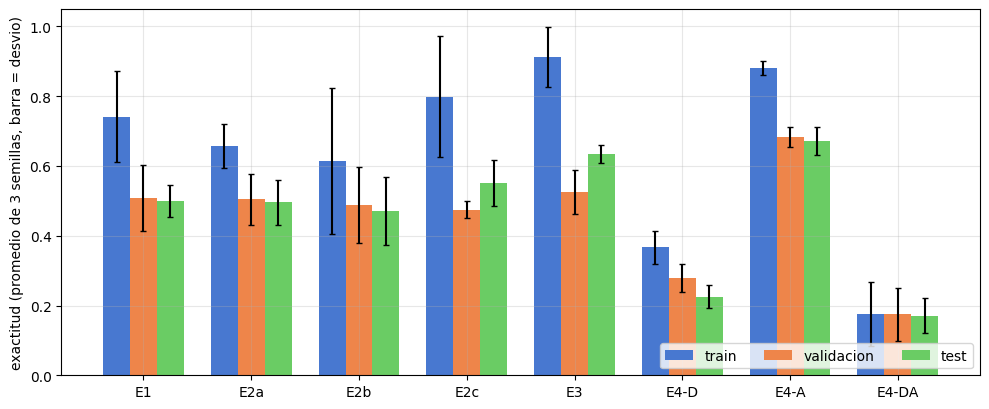

In [15]:
table = summarize(groups)
val_by_group = {k: np.array([r['val_acc'] for r in g]) for k, g in groups.items()}
diffs = []
for name in table.index:
    if name == 'E1':
        diffs.append('-')
        continue
    delta = val_by_group[name] - val_by_group['E1']
    diffs.append(f"{delta.mean():+.3f} (EE {delta.std(ddof=1) / np.sqrt(len(delta)):.3f})")
table['Dif. val vs E1 (EE)'] = diffs
with pd.option_context('display.max_colwidth', 80, 'display.width', 250):
    print(table.to_string())

fig, ax = plt.subplots(figsize=(10, 4.2))
names = list(groups)
positions = np.arange(len(names))
for offset, key, label in [(-0.25, 'train_acc', 'train'), (0.0, 'val_acc', 'validacion'),
                           (0.25, 'test_acc', 'test')]:
    means = [np.mean([r[key] for r in groups[n]]) for n in names]
    errors = [np.std([r[key] for r in groups[n]], ddof=1) for n in names]
    ax.bar(positions + offset, means, width=0.25, yerr=errors, capsize=2, label=label)
ax.set_xticks(positions)
ax.set_xticklabels(names)
ax.set_ylabel('exactitud (promedio de 3 semillas, barra = desvio)')
ax.set_ylim(0, 1.05)
ax.legend(ncol=3, loc='lower right')
plt.tight_layout()
plt.savefig(WORK_DIR / 'p4_03_comparacion_experimentos.png', dpi=110, bbox_inches='tight')
plt.show()

**Entre E1 y E4, solo un cambio supera el ruido entre semillas: la data augmentation.** La sección 6.7 agrega E5.

| Grupo | Experimentos | Acc. val |
|---|---|---|
| Mejor | E4-A | 0.683 |
| Sin diferencia medible entre sí | E3, E1, E2a, E2b, E2c | 0.475 a 0.525 |
| Fallaron | E4-D, E4-DA | 0.279 y 0.175 |

- **E4-A** es mejor que E1 por 0.175 (error estándar 0.066), y que E3 por 0.158
  (error estándar 0.051, 3.1 errores estándar, en las 3 semillas).
- **Las cinco arquitecturas** quedan dentro de 0.05 entre sí. Sus diferencias con
  E1 son de 1 error estándar o menos.
- **E4-D y E4-DA** están muy por debajo de todas las demás. La sección 6.6 mide
  la causa.

**Columna de observaciones.** La brecha entre train y validación baja de 0.39
(E3) a 0.20 (E4-A). E4-A es el único grupo con una corrida en el tope de 50
épocas. La brecha de E4-DA es 0.00, pero no por regularizar bien: la red no
aprende nada.

**El test sigue a la validación** en los grupos extremos: E4-A tiene 0.671 en test,
y E4-DA 0.171. Dentro de las cinco arquitecturas, el orden de test no coincide con
el de validación (E3 tiene 0.633 en test). Con 80 imágenes por conjunto, esos
órdenes no son fiables.

### 6.6 Diagnóstico: por qué falló el Dropout

Este análisis es **posterior a los resultados**. No estaba planificado, y no
cambia la elección del mejor modelo. E4-D y E4-DA quedaron cerca del azar. Además, la exactitud de train de E4-D (0.37) muestra que la red no aprende ni los datos de train.

**Hipótesis.** Las neuronas ocultas de la cabeza densa (128 ReLU) mueren al
inicio del entrenamiento. Una neurona ReLU muerta da 0 para todas las imágenes y
ya no recibe gradiente. Con Dropout de 0.5, la mitad de las neuronas que quedan
se apaga en cada lote, y la red pierde casi toda la información.

**Medición.** Se entrenó E3 con la semilla 1 durante 10 épocas, sin parada temprana. Se usaron cinco configuraciones: la base, solo augmentation, solo Dropout, los dos, y los dos con una tasa de aprendizaje 10 veces menor (`1e-4`). Se midieron tres cosas:

- La pérdida más alta de un lote en la primera época.
- Cuántas de las 128 neuronas ocultas están muertas después de la época 1 y de la época 10. Una neurona muerta da 0 para las 920 imágenes de train.
- El desvío de los logits de validación y la exactitud de validación al final. Un
  desvío cercano a 0 significa que la red da la misma salida para todas las
  imágenes.

Una prueba previa en la CPU del equipo local usa el mismo código. En E4-DA encontró 127 neuronas muertas de 128 después de la primera época.

In [16]:
def diagnose_head(augment, dropout, learning_rate, seed=1, epochs=10):
    # Entrena E3 sin parada temprana y mide la cabeza densa: perdida por lote y neuronas muertas
    torch.manual_seed(seed)
    model = DogCNN(**ARCHS['e3'], dropout=dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    shuffle_generator = torch.Generator().manual_seed(seed)
    augment_generator = torch.Generator().manual_seed(seed + 1000)
    captured = {}
    model.head[3].register_forward_hook(lambda module, inputs, output: captured.__setitem__('h', output))

    @torch.no_grad()
    def dead_units():
        # Una neurona esta muerta si su ReLU da 0 para todas las imagenes de train
        model.eval()
        active = torch.zeros(model.head[2].out_features, dtype=torch.bool, device=DEVICE)
        for i in range(0, len(X_train), 256):
            model(X_train[i:i + 256].to(DEVICE))
            active |= (captured['h'] > 0).any(0)
        return int((~active).sum())

    row = {'augmentation': augment, 'Dropout': dropout, 'tasa': learning_rate}
    for epoch in range(1, epochs + 1):
        model.train()
        order = torch.randperm(len(X_train), generator=shuffle_generator)
        batch_losses = []
        for start in range(0, len(X_train), 32):
            index = order[start:start + 32]
            if len(index) < 2:
                continue
            batch_x, batch_y = X_train[index].to(DEVICE), y_train[index].to(DEVICE)
            if augment:
                batch_x = augment_batch(batch_x, augment_generator)
            loss = F.cross_entropy(model(batch_x), batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        if epoch == 1:
            row['perdida max. de un lote (epoca 1)'] = max(batch_losses)
            row['muertas (epoca 1)'] = dead_units()
    row[f'muertas (epoca {epochs})'] = dead_units()
    val_logits = predict_logits(model, X_val)
    row[f'desvio de logits val (epoca {epochs})'] = val_logits.std().item()
    row[f'acc. val (epoca {epochs})'] = (val_logits.argmax(1) == y_val).float().mean().item()
    return row


diagnostic_configs = [(False, 0.0, 1e-3), (True, 0.0, 1e-3), (False, 0.5, 1e-3),
                      (True, 0.5, 1e-3), (True, 0.5, 1e-4)]
start = time.perf_counter()
diagnostic = pd.DataFrame([diagnose_head(*config) for config in diagnostic_configs])
with pd.option_context('display.width', 250):
    print(diagnostic.round(3).to_string(index=False))
print(f"\nTiempo del diagnostico: {time.perf_counter() - start:.0f} s")
print(f"Perdida de una prediccion constante (ln 8): {np.log(NUM_CLASSES):.3f}")

 augmentation  Dropout  tasa  perdida max. de un lote (epoca 1)  muertas (epoca 1)  muertas (epoca 10)  desvio de logits val (epoca 10)  acc. val (epoca 10)
        False      0.0 0.001                             51.617                112                 113                            3.253                0.550
         True      0.0 0.001                             41.367                117                 118                            1.208                0.438
        False      0.5 0.001                             14.908                125                 127                            0.668                0.200
         True      0.5 0.001                             17.021                125                 128                            0.090                0.125
         True      0.5 0.000                              7.097                 95                 106                            0.498                0.287

Tiempo del diagnostico: 120 s
Perdida de una prediccion c

| Configuración | Pérdida máx. de un lote (época 1) | Muertas (época 1) | Muertas (época 10) | Desvío de logits | Acc. val (época 10) |
|---|---|---|---|---|---|
| Base | 51.6 | 112 | 113 | 3.25 | 0.550 |
| Augmentation | 41.4 | 117 | 118 | 1.21 | 0.438 |
| Dropout | 14.9 | 125 | 127 | 0.67 | 0.200 |
| Dropout y augmentation | 17.0 | 125 | 128 | 0.09 | 0.125 |
| Dropout y augmentation, tasa `1e-4` | 7.1 | 95 | 106 | 0.50 | 0.287 |

La tabla del notebook redondea la tasa `1e-4` a 0.000. Es la última fila.

**La hipótesis se confirma.** En las cinco configuraciones, la mayor parte de las
128 neuronas ocultas muere en la primera época. Ninguna neurona muerta vuelve: el
conteo de la época 10 es igual o mayor que el de la época 1.

- **Sin Dropout sobreviven 10 a 16 neuronas, y alcanzan.** La base llega a 0.550
  de validación en 10 épocas, y la augmentation a 0.438.
- **Con Dropout y la tasa de `1e-3` sobreviven 3 o menos.** Solo con Dropout queda 1 neurona en la
  época 10, y la validación es 0.200. Con Dropout y augmentation mueren las 128.
  Entonces la cabeza da siempre la misma salida (desvío de logits 0.09), y la
  validación es 0.125, exactamente el azar.
- **El salto de la pérdida al inicio es enorme.** La pérdida de un lote llega a
  51.6 en la base, frente a 2.08 de una predicción constante. Con Dropout el
  salto es menor (15 a 17), pero mueren más neuronas. El salto solo no explica
  cuántas mueren.
- **Una tasa 10 veces menor ayuda, pero no lo resuelve.** El salto baja a 7.1,
  mueren 95 en la primera época, y la validación llega a 0.287. Siguen muriendo
  neuronas (106 en la época 10).

Este diagnóstico usa una sola semilla y 10 épocas. Mide el mecanismo, no una solución. La sección 6.7 prueba dos soluciones.
Los valores coinciden con la prueba previa en CPU: la pérdida máxima de la base
fue 51.6 en las dos.

### 6.7 E5 - Una corrección guiada por el diagnóstico

**Este experimento se diseñó después de ver los resultados de E1 a E4, incluido
el test.** El enunciado pide la exactitud de test de cada experimento, así que ya
se vio. La elección sigue usando solo validación. Aun así, el test de E5 es algo
optimista: el cambio se eligió después de saber cómo falló E4.

**El cambio: una cabeza con *global average pooling* (GAP).** La sección 6.6
mostró que la cabeza densa es el punto débil. Tiene 2.1 millones de parámetros, y
la mayoría de sus 128 neuronas ocultas muere en la primera época. Con GAP, cada uno
de los 256 canales de la última etapa se promedia sobre sus 8 x 8 posiciones. Una
sola capa lineal, de 256 a 8, da los logits. La cabeza baja a 2056 parámetros y no
tiene neuronas ReLU ocultas. Es la cabeza de ResNet. La red es E3 con esta cabeza
(E3-GAP).

Variantes, todas con data augmentation y 3 semillas:

- **E5a:** E3-GAP, con el mismo entrenamiento que E4-A (máximo 50 épocas,
  paciencia 10). Aísla el cambio de cabeza.
- **E5b:** E5a con Dropout 0.3 antes de la capa lineal. Mide si el Dropout
  funciona con una cabeza chica.
- **E5c:** E5a con más entrenamiento: máximo 100 épocas, paciencia 20, y una tasa
  con decaimiento coseno (de `1e-3` a 0 en 100 épocas). Una corrida de E4-A llegó
  al tope de 50 épocas.
- **E5d:** E4-DA (cabeza densa, Dropout 0.5 y augmentation) con Leaky ReLU en la
  capa oculta de la cabeza, con pendiente 0.01 para los valores negativos. Es una
  prueba de la causa: solo cambia la activación. Una Leaky ReLU no muere, porque
  su gradiente nunca es 0. El apunte de la Unidad 1 (sección 1.5.5) la presenta
  como la solución a las ReLU muertas.

**Por qué no Softmax en la capa oculta.** Softmax convierte un vector en
probabilidades que suman 1. En una capa oculta, obliga a las 128 neuronas a
competir entre sí, y casi todas quedan cerca de 0. Softmax es la activación de
salida, y `CrossEntropyLoss` ya la aplica.

**Cambios en el código.** `DogCNN` acepta `head='gap'`, y `train_cnn` acepta
`schedule='cosine'`. `DogCNN` acepta también `head_activation='leaky'`. El checkpoint guarda también el estado del decaimiento. Las
configuraciones de E1 a E4 no cambian, así que sus corridas cargan del cache.

**Predicciones, escritas antes de medir.**

- **P7.** E5a mejora a E4-A en validación, de 0.02 a 0.10.
- **P8.** E5b no colapsa: queda a menos de 0.05 de E5a.
- **P9.** E5c mejora a E5a, de 0.02 a 0.08.
- **P10.** E5d aprende: llega a más de 0.50 de validación, frente a 0.175 de E4-DA.
  Si no aprende, las ReLU muertas no son toda la causa.

**Regla.** Es la regla 1 de la sección 4.2. La sección 7 analiza el grupo con
mayor exactitud de validación entre todos los experimentos, E5 incluido.

In [17]:
ARCHS['e3gap'] = {**ARCHS['e3'], 'head': 'gap'}
gap_model = DogCNN(**ARCHS['e3gap'])
print(f"E3-GAP: {count_parameters(gap_model)} parametros, cabeza de {count_parameters(gap_model.head)}")
assert gap_model(X_train[:4]).shape == (4, NUM_CLASSES)
del gap_model

groups['E5a'] = run_group('e5a', 'e3gap', augment=True)
groups['E5b'] = run_group('e5b', 'e3gap', augment=True, dropout=0.3)
groups['E5c'] = run_group('e5c', 'e3gap', augment=True, max_epochs=100, patience=20, schedule='cosine')
ARCHS['e3leaky'] = {**ARCHS['e3'], 'head_activation': 'leaky'}
groups['E5d'] = run_group('e5d', 'e3leaky', augment=True, dropout=0.5)


def paired_val_difference(name, reference):
    # Diferencia de exactitud de validacion por semilla, con su error estandar
    delta = (np.array([r['val_acc'] for r in groups[name]])
             - np.array([r['val_acc'] for r in groups[reference]]))
    return f"{delta.mean():+.3f} (EE {delta.std(ddof=1) / np.sqrt(len(delta)):.3f})"


e5_table = summarize({k: groups[k] for k in ('E4-A', 'E4-DA', 'E5a', 'E5b', 'E5c', 'E5d')})
e5_table['Dif. val vs E4-A (EE)'] = ['-'] + [paired_val_difference(k, 'E4-A')
                                             for k in ('E4-DA', 'E5a', 'E5b', 'E5c', 'E5d')]
print()
with pd.option_context('display.max_colwidth', 80, 'display.width', 250):
    print(e5_table.to_string())
print(f"\nE5b - E5a: {paired_val_difference('E5b', 'E5a')}")
print(f"E5c - E5a: {paired_val_difference('E5c', 'E5a')}")
print(f"E5d - E4-DA: {paired_val_difference('E5d', 'E4-DA')}")

E3-GAP: 1219336 parametros, cabeza de 2056
e5a_s0        [cache] epoca optima  35 de  45  train 0.827  val 0.712  test 0.712  143 s
e5a_s1        [cache] epoca optima  38 de  48  train 0.871  val 0.812  test 0.700  151 s
e5a_s2        [cache] epoca optima   9 de  19  train 0.683  val 0.575  test 0.625  60 s
e5b_s0        [cache] epoca optima  26 de  36  train 0.826  val 0.725  test 0.725  113 s
e5b_s1        [cache] epoca optima  31 de  41  train 0.854  val 0.788  test 0.750  129 s
e5b_s2        [cache] epoca optima  49 de  50  train 0.921  val 0.788  test 0.750  157 s  (llego al maximo de epocas)
e5c_s0        [cache] epoca optima  78 de  98  train 0.997  val 0.850  test 0.837  309 s
e5c_s1        [cache] epoca optima  77 de  97  train 0.996  val 0.900  test 0.825  305 s
e5c_s2        [cache] epoca optima  59 de  79  train 0.993  val 0.863  test 0.812  243 s
e5d_s0        [cache] epoca optima  48 de  50  train 0.702  val 0.675  test 0.663  154 s  (llego al maximo de epocas)
e5d_s1    

| Experimento | Acc. val | Dif. vs E4-A (EE) | Acc. train | Época óptima | Acc. test | Seg./corrida |
|---|---|---|---|---|---|---|
| E4-A (cabeza densa) | 0.683 +- 0.029 | - | 0.881 | 40 | 0.671 | 144 |
| E5a (GAP) | 0.700 +- 0.119 | +0.017 (0.054) | 0.793 | 27 | 0.679 | 118 |
| E5b (GAP y Dropout 0.3) | 0.767 +- 0.036 | +0.083 (0.033) | 0.867 | 35 | 0.742 | 133 |
| **E5c (GAP, 100 épocas, coseno)** | **0.871 +- 0.026** | **+0.188 (0.019)** | 0.995 | 71 | **0.825** | 286 |
| E5d (densa, Leaky ReLU, Dropout 0.5) | 0.625 +- 0.050 | -0.058 (0.017) | 0.682 | 47 | 0.617 | 154 |

**P7 falló: la cabeza GAP sola no mejora de forma medible.** E5a supera a E4-A por
0.017, menos de 1 error estándar. Es mejor en 2 de las 3 semillas. En la semilla
2, la parada temprana cortó en la época 19, con la mejor época en la 9. La cabeza
GAP tiene un 63% menos de parámetros en total, y no pierde exactitud.

**P8 se cumple en lo principal: con una cabeza chica, el Dropout ya no rompe el
entrenamiento.** E5b queda 0.067 por encima de E5a (error estándar 0.074). Está
fuera del margen de 0.05 que se predijo, pero hacia arriba, y la diferencia no se
distingue del ruido. El Dropout de 0.3 sobre la cabeza GAP funciona.

**P9 se cumple, con un efecto mayor que el previsto.** E5c supera a E5a por 0.171
(error estándar 0.060), en las 3 semillas. La predicción era de 0.02 a 0.08. E5c es el
mejor experimento: 0.871 de validación, 0.188 por encima de E4-A (unos 10 errores
estándar).

**P10 se cumple: con Leaky ReLU, el Dropout de 0.5 deja de colapsar.** E5d llega a
0.625, frente a 0.175 de E4-DA, con una diferencia de +0.450 (error estándar
0.022). La única diferencia entre los dos es la activación de la cabeza. Es una
prueba directa de que las ReLU muertas causaron la falla de E4-DA. Las tres
corridas de E5d llegaron al tope de 50 épocas, con su mejor época en la 44 a 48.

**Qué parte del cambio explica la mejora.** E5c cambia tres cosas respecto de E5a:
el tope de épocas, la paciencia y el decaimiento coseno. Esas tres cosas no se separaron.
Tampoco se probó la cabeza densa con el entrenamiento largo. Por eso no se sabe
cuánto de la mejora de E5c sobre E4-A viene de la cabeza GAP. E5a muestra que,
con el entrenamiento corto, la cabeza GAP sola no cambia la exactitud.

## 7. Análisis del mejor modelo

### 7.1 Elección del mejor modelo y curvas de aprendizaje

Se elige la configuración con mayor exactitud de validación promedio (regla 1 de
la sección 4.2). Dentro de esa configuración, se usa la semilla con mayor
exactitud de validación. Si hay empate, gana la menor pérdida de validación.
La elección usa solo validación. El test no participa.

Se muestran las curvas de pérdida y de exactitud, de train y de validación, por
época. La línea vertical marca la época que conserva la parada temprana.

Mejor configuracion por validacion: E5c (exactitud de validacion promedio 0.871)
Mejor corrida dentro de la configuracion: e5c_s1 (semilla 1, epoca optima 77)


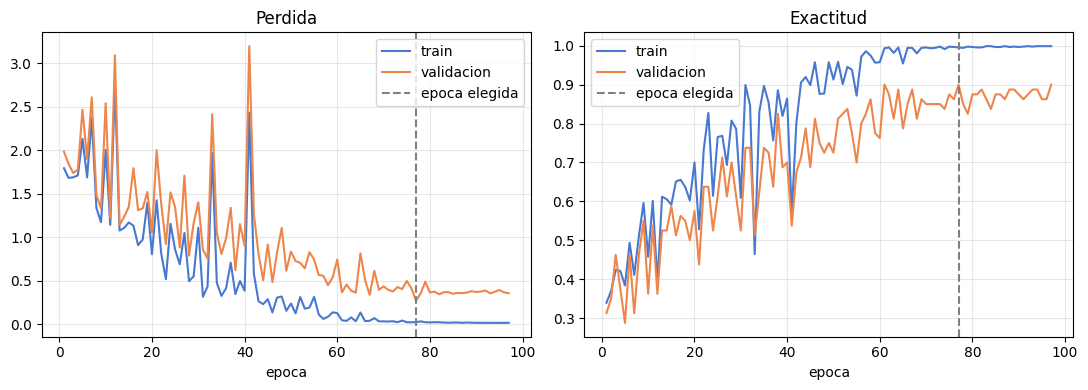

Epoca elegida 77: train 0.996, val 0.900, brecha de exactitud 0.096, brecha de perdida 0.247


In [18]:
group_val = {k: np.mean([r['val_acc'] for r in g]) for k, g in groups.items()}
group_loss = {k: np.mean([r['val_loss'] for r in g]) for k, g in groups.items()}
best_group = max(group_val, key=lambda k: (round(group_val[k], 6), -group_loss[k]))
best_run = max(groups[best_group], key=lambda r: (round(r['val_acc'], 6), -r['val_loss']))
print(f"Mejor configuracion por validacion: {best_group} "
      f"(exactitud de validacion promedio {group_val[best_group]:.3f})")
print(f"Mejor corrida dentro de la configuracion: {best_run['run_id']} "
      f"(semilla {best_run['seed']}, epoca optima {best_run['best_epoch']})")

history = best_run['history']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history['epoch'], history['train_loss'], label='train')
axes[0].plot(history['epoch'], history['val_loss'], label='validacion')
axes[0].set_title('Perdida')
axes[1].plot(history['epoch'], history['train_acc'], label='train')
axes[1].plot(history['epoch'], history['val_acc'], label='validacion')
axes[1].set_title('Exactitud')
for ax in axes:
    ax.axvline(best_run['best_epoch'], color='gray', linestyle='--', label='epoca elegida')
    ax.set_xlabel('epoca')
    ax.legend()
plt.tight_layout()
plt.savefig(WORK_DIR / 'p4_04_curvas_mejor_modelo.png', dpi=110, bbox_inches='tight')
plt.show()
chosen_row = history[history['epoch'] == best_run['best_epoch']].iloc[0]
print(f"Epoca elegida {best_run['best_epoch']}: train {chosen_row['train_acc']:.3f}, "
      f"val {chosen_row['val_acc']:.3f}, brecha de exactitud {chosen_row['train_acc'] - chosen_row['val_acc']:.3f}, "
      f"brecha de perdida {chosen_row['val_loss'] - chosen_row['train_loss']:.3f}")

**La corrida elegida es E5c, semilla 1.** Tiene la mayor exactitud de validación
de E5c (0.900). La parada ocurrió en la época 97, y el modelo conserva la
época 77.

**Lectura de las curvas.**

- **Hasta la época 45, el entrenamiento es inestable.** La pérdida de validación
  salta varias veces por encima de 2, y una vez hasta cerca de 3.2 en la época
  41. La tasa todavía está cerca de `1e-3`.
- **Desde la época 45, las curvas se estabilizan.** El decaimiento coseno baja la
  tasa a la mitad en la época 50, y a menos de un quinto en la 75. La pérdida de
  validación baja a cerca de 0.4, y la exactitud de validación queda entre 0.84 y
  0.90.
- **Train llega a 1.0 en la época 60.** La pérdida de train baja a casi 0.

**Hay sobreajuste, pero la validación no empeora.** En la época elegida, la
brecha de exactitud es 0.096 y la de pérdida 0.247. Desde la época 60, train ya no tiene más que aprender, y la pérdida de validación queda plana, cerca de 0.4. En E4-A oscilaba entre 1.0 y 1.6.

**La época elegida depende menos del ruido que en E4-A.** De la época 60 a la 97, la
exactitud de validación se mueve poco. Otra época de ese tramo da un resultado
parecido. La inestabilidad del inicio sugiere que una tasa de `1e-3` es alta
para esta red. Esto no se midió.

### 7.2 Exactitud en test, con intervalo de confianza

El mejor modelo se mide en test. Con 80 imágenes, el número de aciertos es
una variable binomial. Se calcula el intervalo de Wilson de 95% y se compara con
el azar (12.5%). También se compara con E1 sobre las mismas 80 imágenes, con un
*bootstrap* pareado de 10000 remuestreos. En cada remuestreo se eligen 80 imágenes
con reposición y se calcula la diferencia de exactitud entre los dos modelos.
Se usa `np.random.default_rng`, como en el Problema 3.

Para E1 se usa la corrida con la misma semilla que el mejor modelo.

In [19]:
test_true = y_test.numpy()
best_pred = best_run['test_logits'].argmax(1).numpy()
correct = int((best_pred == test_true).sum())
interval = binomtest(correct, len(test_true)).proportion_ci(confidence_level=0.95, method='wilson')
print(f"Mejor modelo ({best_run['run_id']}): {correct} de {len(test_true)} aciertos, "
      f"exactitud de test {correct / len(test_true):.4f}, IC95 de Wilson [{interval.low:.3f}, {interval.high:.3f}]")
print(f"Azar: {1 / NUM_CLASSES:.3f}")
print(f"Exactitud de las 3 semillas de {best_group} en test: "
      f"{[round(r['test_acc'], 4) for r in groups[best_group]]}")

e1_run = next(r for r in groups['E1'] if r['seed'] == best_run['seed'])
e1_pred = e1_run['test_logits'].argmax(1).numpy()
bootstrap_rng = np.random.default_rng(SEED)
resample = bootstrap_rng.integers(0, len(test_true), size=(10_000, len(test_true)))
hits_best = (best_pred == test_true).astype(float)
hits_e1 = (e1_pred == test_true).astype(float)
differences = hits_best[resample].mean(axis=1) - hits_e1[resample].mean(axis=1)
low, high = np.percentile(differences, [2.5, 97.5])
print(f"\nE1 (semilla {best_run['seed']}): {int(hits_e1.sum())} aciertos, exactitud {hits_e1.mean():.4f}")
print(f"Diferencia pareada (mejor - E1): observada {hits_best.mean() - hits_e1.mean():+.4f}, "
      f"media bootstrap {differences.mean():+.4f}, IC95 [{low:+.4f}, {high:+.4f}]")
print(f"Imagenes que acierta solo el mejor: {int(((hits_best == 1) & (hits_e1 == 0)).sum())}, "
      f"solo E1: {int(((hits_best == 0) & (hits_e1 == 1)).sum())}")

Mejor modelo (e5c_s1): 66 de 80 aciertos, exactitud de test 0.8250, IC95 de Wilson [0.727, 0.893]
Azar: 0.125
Exactitud de las 3 semillas de E5c en test: [0.8375, 0.825, 0.8125]

E1 (semilla 1): 43 aciertos, exactitud 0.5375
Diferencia pareada (mejor - E1): observada +0.2875, media bootstrap +0.2875, IC95 [+0.1625, +0.4125]
Imagenes que acierta solo el mejor: 28, solo E1: 5


**El mejor modelo acierta 66 de 80 imágenes de test: 0.825, con un intervalo de
Wilson de 95% de [0.727, 0.893].** El azar da 0.125. Las tres semillas de E5c
dan 0.838, 0.825 y 0.812 en test. La semilla elegida no es un caso aislado.

**Frente a E1 con la misma semilla, la mejora es clara.** La diferencia pareada es
+0.2875, con un intervalo bootstrap de [+0.1625, +0.4125]. El mejor modelo acierta
28 imágenes que E1 falla, y E1 acierta 5 que el mejor falla. Con la media de las
semillas, la diferencia de test es 0.825 - 0.500 = 0.325.

**Frente a E4-A, el mejor modelo anterior, acierta 11 imágenes más** (66 frente a
55). La media de las semillas sube de 0.671 a 0.825 en test.

**Cautelas.**

- **El test es algo optimista.** E5 se diseñó después de ver el test de E1 a E4, y
  se eligió entre 12 grupos con 80 imágenes de validación. La semilla elegida tiene
  0.900 en validación y 0.825 en test. Esa caída es la esperable cuando se elige el
  máximo de varias mediciones con ruido.
- **El intervalo tiene 0.17 de ancho.** Con 80 imágenes, una exactitud de 0.825 es
  compatible con valores reales de 0.73 a 0.89.

### 7.3 Matriz de confusión y exactitud por raza

Se muestra la matriz de confusión sobre test. Cada fila es la raza real y cada
columna la raza predicha. También se listan los pares de razas que más se
confunden. Cada raza tiene 10 imágenes de test. Un número por raza tiene un
margen de error grande, así que el análisis mira los patrones y no los valores sueltos.

Para medir la predicción P6, se cuentan los errores dentro de los dos grupos de
razas parecidas. Esos grupos son el trío de Collies y el par Labrador-Golden Retriever. Las
razas "distintas" no forman un grupo de razas parecidas. Un error entre dos de
ellas cuenta como un error fuera de los grupos.

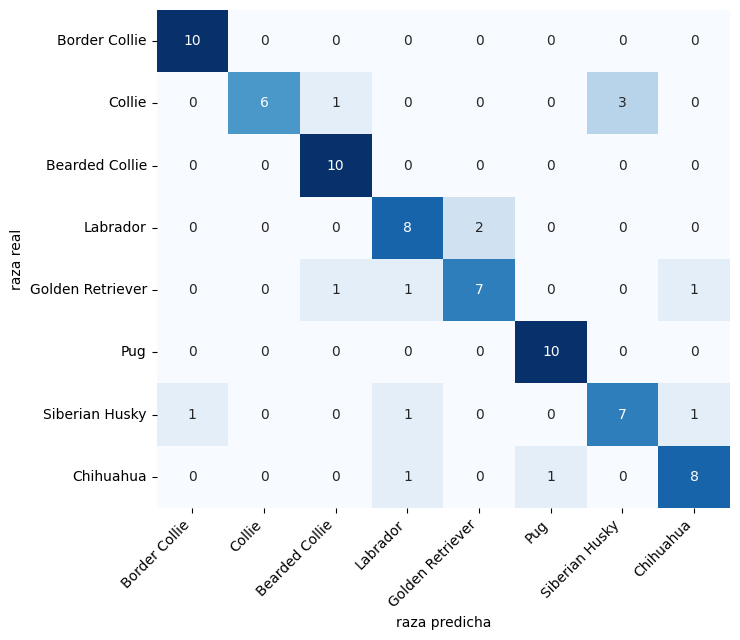

                Border Collie  Collie  Bearded Collie  Labrador  Golden Retriever  Pug  Siberian Husky  Chihuahua
aciertos de 10             10       6              10         8                 7   10               7          8

Confusiones (real -> predicha, cantidad):
  Collie             -> Siberian Husky     3
  Labrador           -> Golden Retriever   2
  Collie             -> Bearded Collie     1
  Golden Retriever   -> Bearded Collie     1
  Golden Retriever   -> Labrador           1
  Golden Retriever   -> Chihuahua          1
  Siberian Husky     -> Border Collie      1
  Siberian Husky     -> Labrador           1
  Siberian Husky     -> Chihuahua          1
  Chihuahua          -> Labrador           1
  Chihuahua          -> Pug                1

Errores totales: 14. Dentro del trio de Collies: 1. Dentro del par Labrador-Golden: 3. Fuera de los dos grupos: 10
Los dos grupos son 8 de las 56 celdas fuera de la diagonal (14.3%)


In [20]:
matrix = confusion_matrix(test_true, best_pred, labels=range(NUM_CLASSES))
fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=BREEDS, yticklabels=BREEDS)
ax.set_xlabel('raza predicha')
ax.set_ylabel('raza real')
ax.grid(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(WORK_DIR / 'p4_05_matriz_confusion.png', dpi=110, bbox_inches='tight')
plt.show()

per_class = pd.DataFrame({'aciertos de 10': np.diag(matrix)}, index=BREEDS)
print(per_class.T.to_string())
off_diagonal = [(BREEDS[i], BREEDS[j], int(matrix[i, j])) for i in range(NUM_CLASSES)
                for j in range(NUM_CLASSES) if i != j and matrix[i, j] > 0]
off_diagonal.sort(key=lambda item: -item[2])
print("\nConfusiones (real -> predicha, cantidad):")
for real, predicted, amount in off_diagonal:
    print(f"  {real:18s} -> {predicted:18s} {amount}")

similar_group = {'Border Collie': 'collies', 'Collie': 'collies', 'Bearded Collie': 'collies',
                 'Labrador': 'retrievers', 'Golden Retriever': 'retrievers'}
total_errors = sum(n for _, _, n in off_diagonal)
within_collies = sum(n for r, p, n in off_diagonal if similar_group.get(r) == similar_group.get(p) == 'collies')
within_retrievers = sum(n for r, p, n in off_diagonal
                        if similar_group.get(r) == similar_group.get(p) == 'retrievers')
print(f"\nErrores totales: {total_errors}. Dentro del trio de Collies: {within_collies}. "
      f"Dentro del par Labrador-Golden: {within_retrievers}. "
      f"Fuera de los dos grupos: {total_errors - within_collies - within_retrievers}")
possible_pairs = 3 * 2 + 2 * 1
print(f"Los dos grupos son {possible_pairs} de las {NUM_CLASSES * (NUM_CLASSES - 1)} celdas fuera de "
      f"la diagonal ({possible_pairs / (NUM_CLASSES * (NUM_CLASSES - 1)) * 100:.1f}%)")

**Aciertos por raza (de 10):** Border Collie 10, Collie 6, Bearded Collie 10,
Labrador 8, Golden Retriever 7, Pug 10, Siberian Husky 7 y Chihuahua 8.

**Quedan 14 errores, frente a 25 de E4-A.** Ahora los errores sí se acercan a las
razas parecidas:

| Dónde caen los errores de test | E4-A (25 errores) | E5c (14 errores) | % de las celdas |
|---|---|---|---|
| Dentro del trío de Collies | 0 | 1 | 10.7% |
| Dentro del par Labrador-Golden | 2 | 3 | 3.6% |
| Fuera de los dos grupos | 23 | 10 | 85.7% |

**P6 se cumple en parte con el mejor modelo.** Los dos grupos son el 14.3% de las
celdas fuera de la diagonal, y reciben el 29% de los errores de E5c (4 de 14). Es
el doble de lo esperable por azar. Pero la mayoría de los errores, 10 de 14, sigue
fuera de los grupos. Con E4-A, la predicción falló (8%).

**La atracción hacia Husky baja, pero no desaparece.** Con E4-A, 11 errores
predecían Husky. Con E5c son 3, todos de Collie. Collie es la raza con menos
aciertos (6 de 10).

**Los errores de Labrador y Golden Retriever son el par que se esperaba.** Dos
Labradores se predicen como Golden, y un Golden como Labrador.

Con 10 imágenes por raza, los intervalos son anchos: 6 de 10 va de 0.31 a 0.83, y
10 de 10 de 0.72 a 1.00. No se afirma un orden entre razas.

### 7.4 Ejemplos de predicciones correctas e incorrectas

El enunciado pide al menos 5 ejemplos de cada tipo. Se muestran 5 aciertos y hasta
10 errores. Los aciertos son una muestra aleatoria con semilla fija. Los errores
son los de mayor confianza, porque son los más informativos: el modelo estaba
seguro y se equivocó. Cada imagen muestra la raza real, la predicha y la
probabilidad de la predicha. Se muestran las imágenes de 128 x 128 que ve la red.

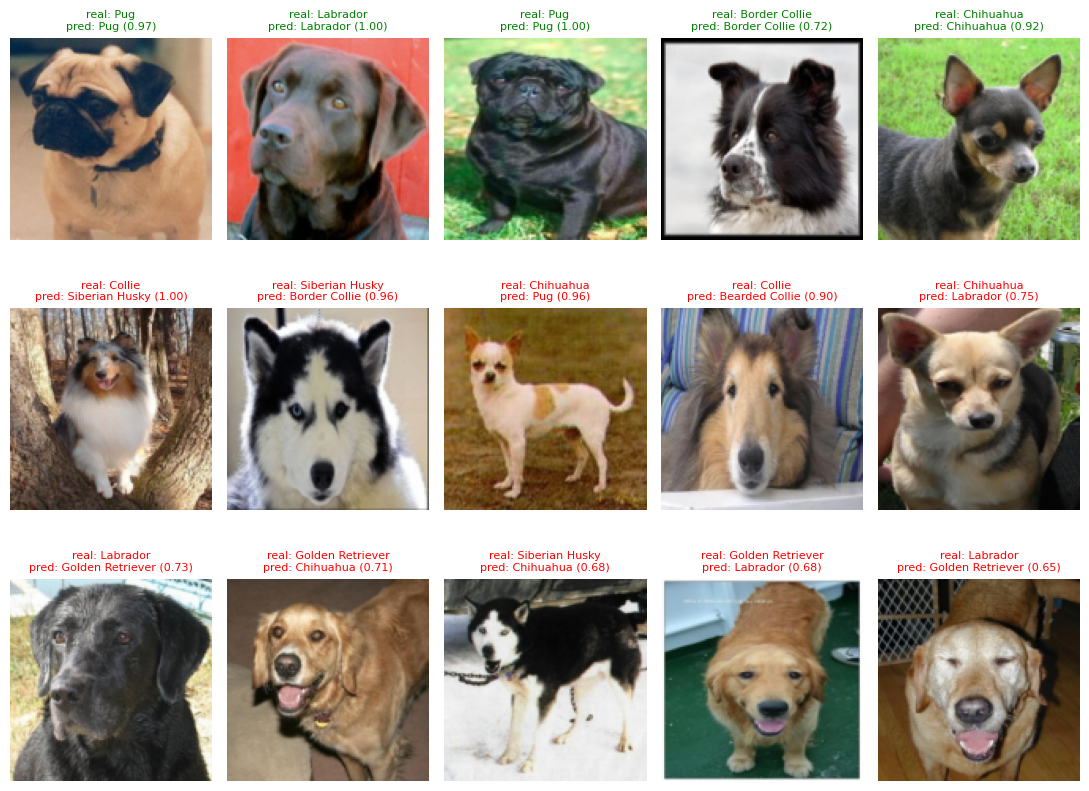

Errores totales en test: 14. Se muestran 10.
Confianza media de los aciertos: 0.921, de los errores: 0.711


In [21]:
probabilities = F.softmax(best_run['test_logits'], dim=1).numpy()
confidence = probabilities[np.arange(len(test_true)), best_pred]
wrong_index = np.where(best_pred != test_true)[0]
wrong_index = wrong_index[np.argsort(-confidence[wrong_index])][:10]
right_pool = np.where(best_pred == test_true)[0]
right_index = np.random.default_rng(SEED).choice(right_pool, size=5, replace=False)


def show_examples(indices, axes_row):
    for ax, index in zip(axes_row, indices):
        ax.imshow(X_test_raw[index].permute(1, 2, 0).numpy())
        ax.set_title(f"real: {BREEDS[test_true[index]]}\npred: {BREEDS[best_pred[index]]} "
                     f"({confidence[index]:.2f})", fontsize=8,
                     color='green' if best_pred[index] == test_true[index] else 'red')
        ax.axis('off')
    for ax in axes_row[len(indices):]:
        ax.axis('off')


fig, axes = plt.subplots(3, 5, figsize=(11, 8.5))
show_examples(right_index, axes[0])
show_examples(wrong_index[:5], axes[1])
show_examples(wrong_index[5:10], axes[2])
plt.tight_layout()
plt.savefig(WORK_DIR / 'p4_06_ejemplos_predicciones.png', dpi=110, bbox_inches='tight')
plt.show()
print(f"Errores totales en test: {int((best_pred != test_true).sum())}. Se muestran {len(wrong_index)}.")
print(f"Confianza media de los aciertos: {confidence[best_pred == test_true].mean():.3f}, "
      f"de los errores: {confidence[best_pred != test_true].mean():.3f}")

**Aciertos.** Los 5 aciertos al azar tienen confianzas de 0.72 a 1.00. El modelo
reconoce Pugs y un Labrador chocolate con confianza de 0.97 a 1.00.

**Errores de alta confianza** (lectura de las imágenes, no probada):

- **Collie -> Siberian Husky (1.00).** Es la misma foto que E4-A ya fallaba: un
  Collie marrón, blanco y gris, sentado en un tronco.
- **Siberian Husky -> Border Collie (0.96).** Un Husky de cara blanca y negra. El
  Border Collie es la raza blanca y negra de train. Es coherente con una hipótesis formulada con E4-A: el modelo usa el color del pelo. E4-A mandaba 11 errores a Husky, varios de pelo claro. La hipótesis no se probó.
- **Chihuahua -> Pug (0.96) y Chihuahua -> Labrador (0.75).** Un Chihuahua blanco con
  manchas y uno crema.
- **Collie -> Bearded Collie (0.90).** Una cara de Collie de pelo largo, dentro del
  trío.
- **Labrador -> Golden (0.73 y 0.65), Golden -> Labrador (0.68) y Golden ->
  Chihuahua (0.71).** Errores entre perros dorados o crema, con confianza media.

**El Chihuahua gris que E4-A llamaba Husky ya no es un error.** E5c falla solo 2
Chihuahuas, y son los dos de la figura, otros perros.

La confianza media es 0.921 en los aciertos y 0.711 en los errores. La confianza media de los errores es parecida a la de E4-A (0.711 frente a 0.696). Pero los errores más seguros lo son menos. Los 10 errores mostrados de E4-A tenían 0.82 o más. En E5c, 7 de los 10 tienen menos de 0.91.

## 8. Conclusiones, limitaciones y propuestas

**Resumen de las predicciones, escritas antes de medir**

| Predicción | Resultado |
|---|---|
| P1. E1 llega a 55-70% en validación y casi 100% en train | Falló en parte: 0.508 en validación, y 0.74 en train en la época elegida |
| P2. E2a no mejora a E1 de forma clara | Se cumple: -0.004 (EE 0.044) |
| P3. E2b y E2c quedan cerca de E2a | Se cumple: diferencias de 1 EE o menos |
| P4. E3 queda cerca de E2a | Se cumple: +0.021 (EE 0.021) |
| P5. La augmentation tiene el mayor efecto (5 a 10 puntos), el Dropout aporta poco | Falló en parte: la augmentation aporta 15.8 puntos, y el Dropout rompe el entrenamiento |
| P6. Las confusiones se concentran en los Collies y en Labrador-Golden | Falló con E4-A (8% de los errores). Se cumple en parte con E5c (29%) |
| P7. La cabeza GAP mejora a E4-A de 0.02 a 0.10 | Falló: +0.017 (EE 0.054) |
| P8. Con la cabeza GAP, el Dropout no colapsa | Se cumple: +0.067 (EE 0.074) |
| P9. El entrenamiento largo con coseno mejora a E5a de 0.02 a 0.08 | Se cumple, con más efecto: +0.171 (EE 0.060) |
| P10. Con Leaky ReLU, E4-DA aprende (más de 0.50) | Se cumple: 0.625, frente a 0.175 |

**Lo aprendido**

- **Con 920 imágenes de train, la arquitectura no cambió la exactitud.** Más
  profundidad, filtros de 5 x 5, stride 2 y bloques residuales quedan dentro del
  ruido entre semillas. El costo sí cambia: E2c tarda 14 s por corrida y E2b 150
  s, con la misma exactitud.
- **Lo que más importó fue el entrenamiento, no la arquitectura.** La data
  augmentation sube la validación de 0.525 a 0.683. El entrenamiento largo con
  decaimiento coseno, sobre la cabeza GAP, la sube a 0.871. El mejor modelo (E5c)
  acierta 66 de 80 imágenes de test: 0.825 [0.727, 0.893].
- **El Dropout falló por las ReLU muertas, y esto se probó.** La sección 6.6 mide que
  las neuronas ocultas de la cabeza densa mueren en la primera época. La sección
  6.7 cambia solo la activación por Leaky ReLU, y el modelo pasa de 0.175 a 0.625.
  Con una cabeza chica (GAP), el Dropout de 0.3 también funciona. Es el problema
  que motivó Leaky ReLU en el Problema 1, donde no se midió.
- **Medir en lugar de suponer cambió el resultado.** Sin el diagnóstico de la sección 6.6, la conclusión era que el Dropout es malo para este problema. La
  medición mostró una causa concreta, y la causa sugirió la corrección.
- **Los errores cambian con el modelo.** E4-A mandaba la mayor parte de los errores
  a Husky y Labrador. E5c tiene menos errores, y más de ellos caen entre razas
  parecidas.

**Limitaciones**

- **Validación y test tienen 80 imágenes.** Un acierto cambia la exactitud en
  1.25 puntos, y la exactitud por raza se mide con 10 imágenes.
- **3 semillas y una sola división.** Solo diferencias de unos 0.1 o más se
  distinguen del ruido con claridad.
- **E5 se diseñó después de ver el test de E1 a E4.** La elección usó solo
  validación, pero el test de E5c es algo optimista. La semilla elegida baja de
  0.900 en validación a 0.825 en test.
- **Las partes de E5c no se separaron.** No se sabe cuánto aportan el tope de épocas,
  la paciencia, el decaimiento coseno y la cabeza GAP por separado.
- **La base de E4 se eligió con márgenes menores que el ruido.** E3 ganó con 0.525
  frente a 0.508 de E1. La elección depende de las semillas.
- **E5d llegó al tope de 50 épocas en las 3 semillas**, y E5b en una.
- **Quedan sin probar un bloque Inception y una resolución de 224.**

**Propuestas de mejora (ninguna se probó en este trabajo)**

- **Separar las partes de E5c:** la cabeza densa con el entrenamiento largo, y la
  cabeza GAP con 100 épocas sin coseno.
- **Una tasa inicial menor o un *warmup*,** por la inestabilidad de las primeras
  45 épocas de E5c.
- **Combinar E5b y E5c:** Dropout de 0.3 con el entrenamiento largo.
- **Grad-CAM**, para ver si el modelo usa el color del pelo o la forma.
- **Resolución de 224**, para el detalle fino de las razas parecidas.